## 32q lattice

Simulation of Harper-Hofstadter model using parametric coupling scheme with calibration of modulation amplitudes and uniform bare hopping rates

### Aharonov-Bohm interference

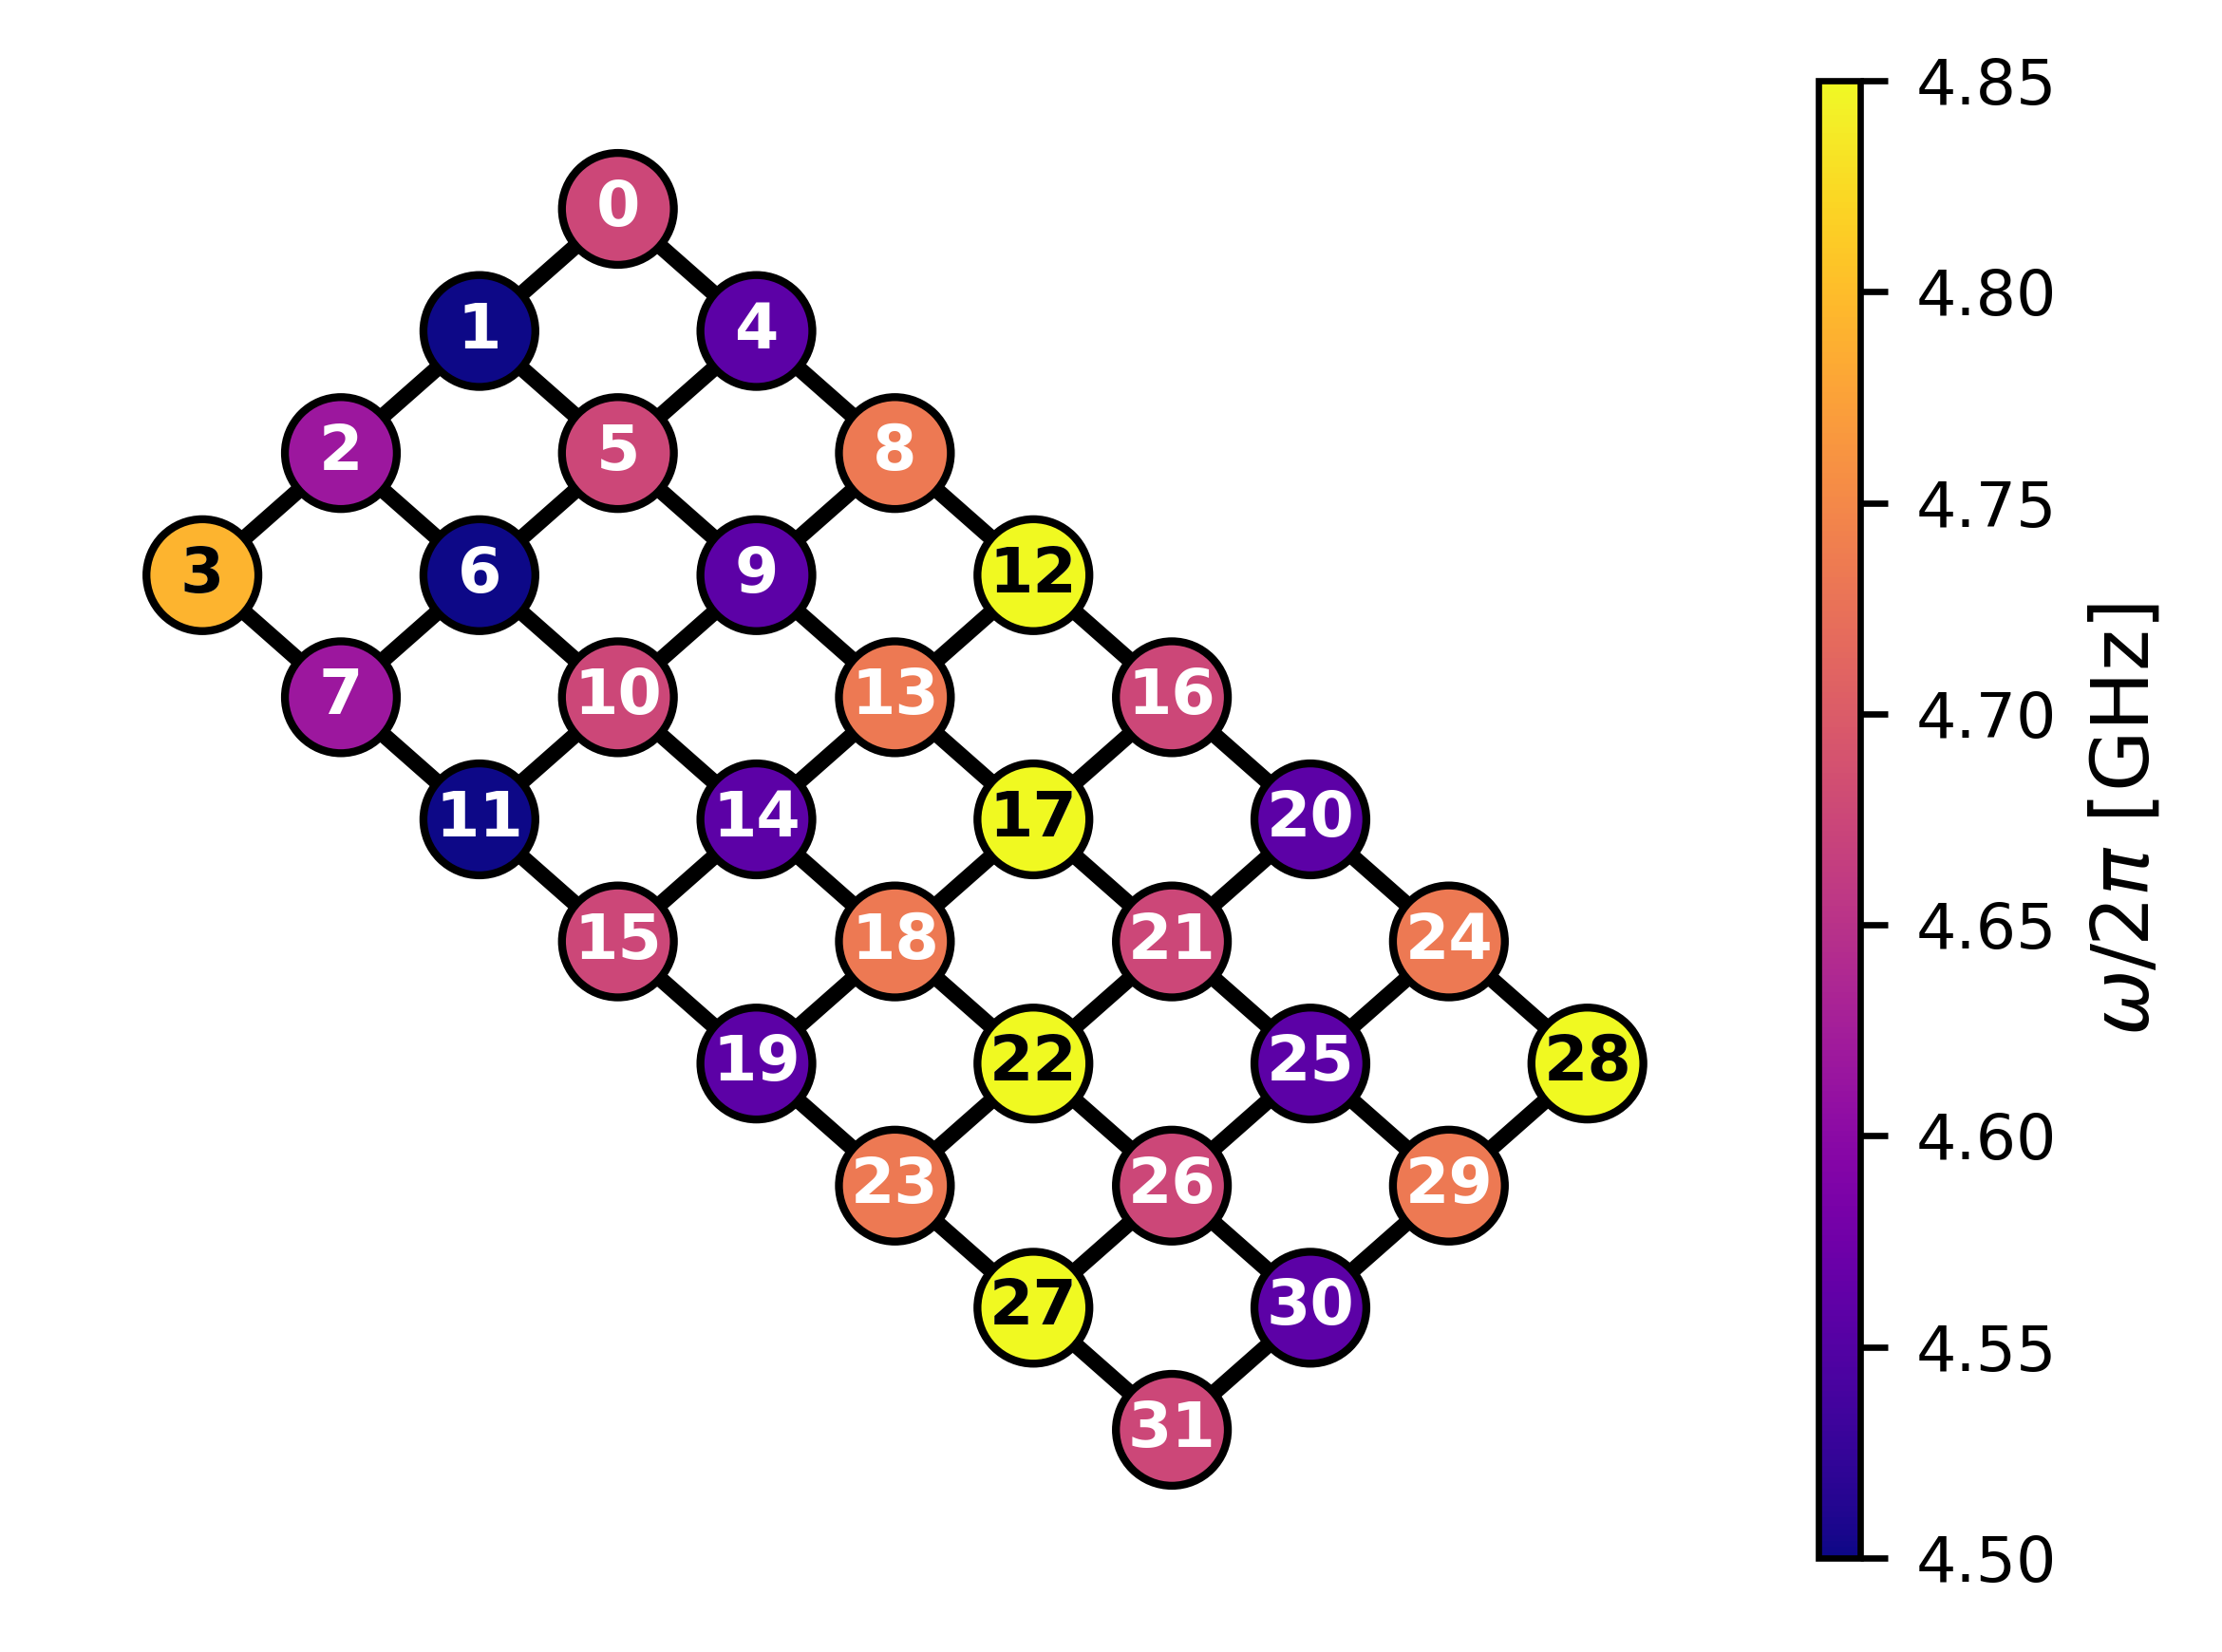

In [16]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

In [1]:
from Processor import *
from Interpreter import *
from tools import *

import qutip as qt
import numpy as np
from numpy import pi
from scipy import sparse as sp
import pickle

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import Image, display
import warnings

warnings.filterwarnings("ignore")

In [4]:
# DC-frequency layout:
# '0': 4.675 * 2 * pi, '1': 4.5 * 2 * pi, '4': 4.55833333 * 2 * pi, '2': 4.61666667 * 2 * pi,
# '8': 4.73333333 * 2 * pi, '3': 4.79166667 * 2 * pi, '12': 4.85 * 2 * pi, '16': 4.675 * 2 * pi,
# '20': 4.55833333 * 2 * pi, '24': 4.73333333 * 2 * pi, '28': 4.85 * 2 * pi

M, N = 8, 4 # width & height of rectangular lattice
J0_nearest = 0.0059 * 2 * pi # nearest-neighbors coupling
J0_next_nearest = J0_nearest / 10 # next nearest-neighbors coupling
next_nearest = False
Js = CreateCouplingMatrix(M, N, J0_nearest, J0_next_nearest, next_nearest)
modul_ampls_init = None
site_destroy_ops_init = None
anharmonicity = -0 * 2 * pi # on-site interaction

device_config = {'M': M, 'N': N, 'num_sites': M * N,

                # base frequencies for each column of lattice
                'dc_freqs_base': {'3': 4.79166667 * 2 * pi, '2': 4.61666667 * 2 * pi, '1': 4.5 * 2 * pi, '0': 4.675 * 2 * pi,
                                  '4': 4.55833333 * 2 * pi, '8': 4.73333333 * 2 * pi, '12': 4.85 * 2 * pi, '16': 4.675 * 2 * pi,
                                  '20': 4.55833333 * 2 * pi, '24': 4.73333333 * 2 * pi, '28': 4.85 * 2 * pi},
                # columns of certain base frequency
                'sites_columns': [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14, 19),
                                  (8, 13, 18, 23), (12, 17, 22, 27), (16, 21, 26, 31),
                                  (20, 25, 30), (24, 29), (28,)],
                'modul_ampls_init': modul_ampls_init, 'site_destroy_ops_init': site_destroy_ops_init,

                'Js': Js, # upper triangular coupling matrix
                'J_eff': J0_nearest * 0.34, # target hopping rate between nearest neighbors
                'anharmonicity': anharmonicity,
                'space_trunc': 2, # atom Hilbert space truncation
                'total_population': 1, # total excitations number
                'max_simultaneously_above_first_excited': 0} # number of atoms in >= 2nd state

processor = Processor(device_config)

On-site interaction is off
Low energy subspace of 33 kets has been created
Creating destroy operators...
Destroy operators have been created
Calibrating modulation amplitudes...
Effective coupling of site №2 with neighbor №3 is                        2.006 MHz
Effective coupling of site №7 with neighbor №3 is                        2.006 MHz
Effective coupling of site №1 with neighbor №2 is                        2.006 MHz
Effective coupling of site №6 with neighbor №7 is                        2.006 MHz
Effective coupling of site №6 with neighbor №2 is                        2.006 MHz
Effective coupling of site №11 with neighbor №7 is                        2.006 MHz
Effective coupling of site №0 with neighbor №1 is                        2.006 MHz
Effective coupling of site №5 with neighbor №6 is                        2.006 MHz
Effective coupling of site №5 with neighbor №1 is                        2.006 MHz
Effective coupling of site №10 with neighbor №11 is                       

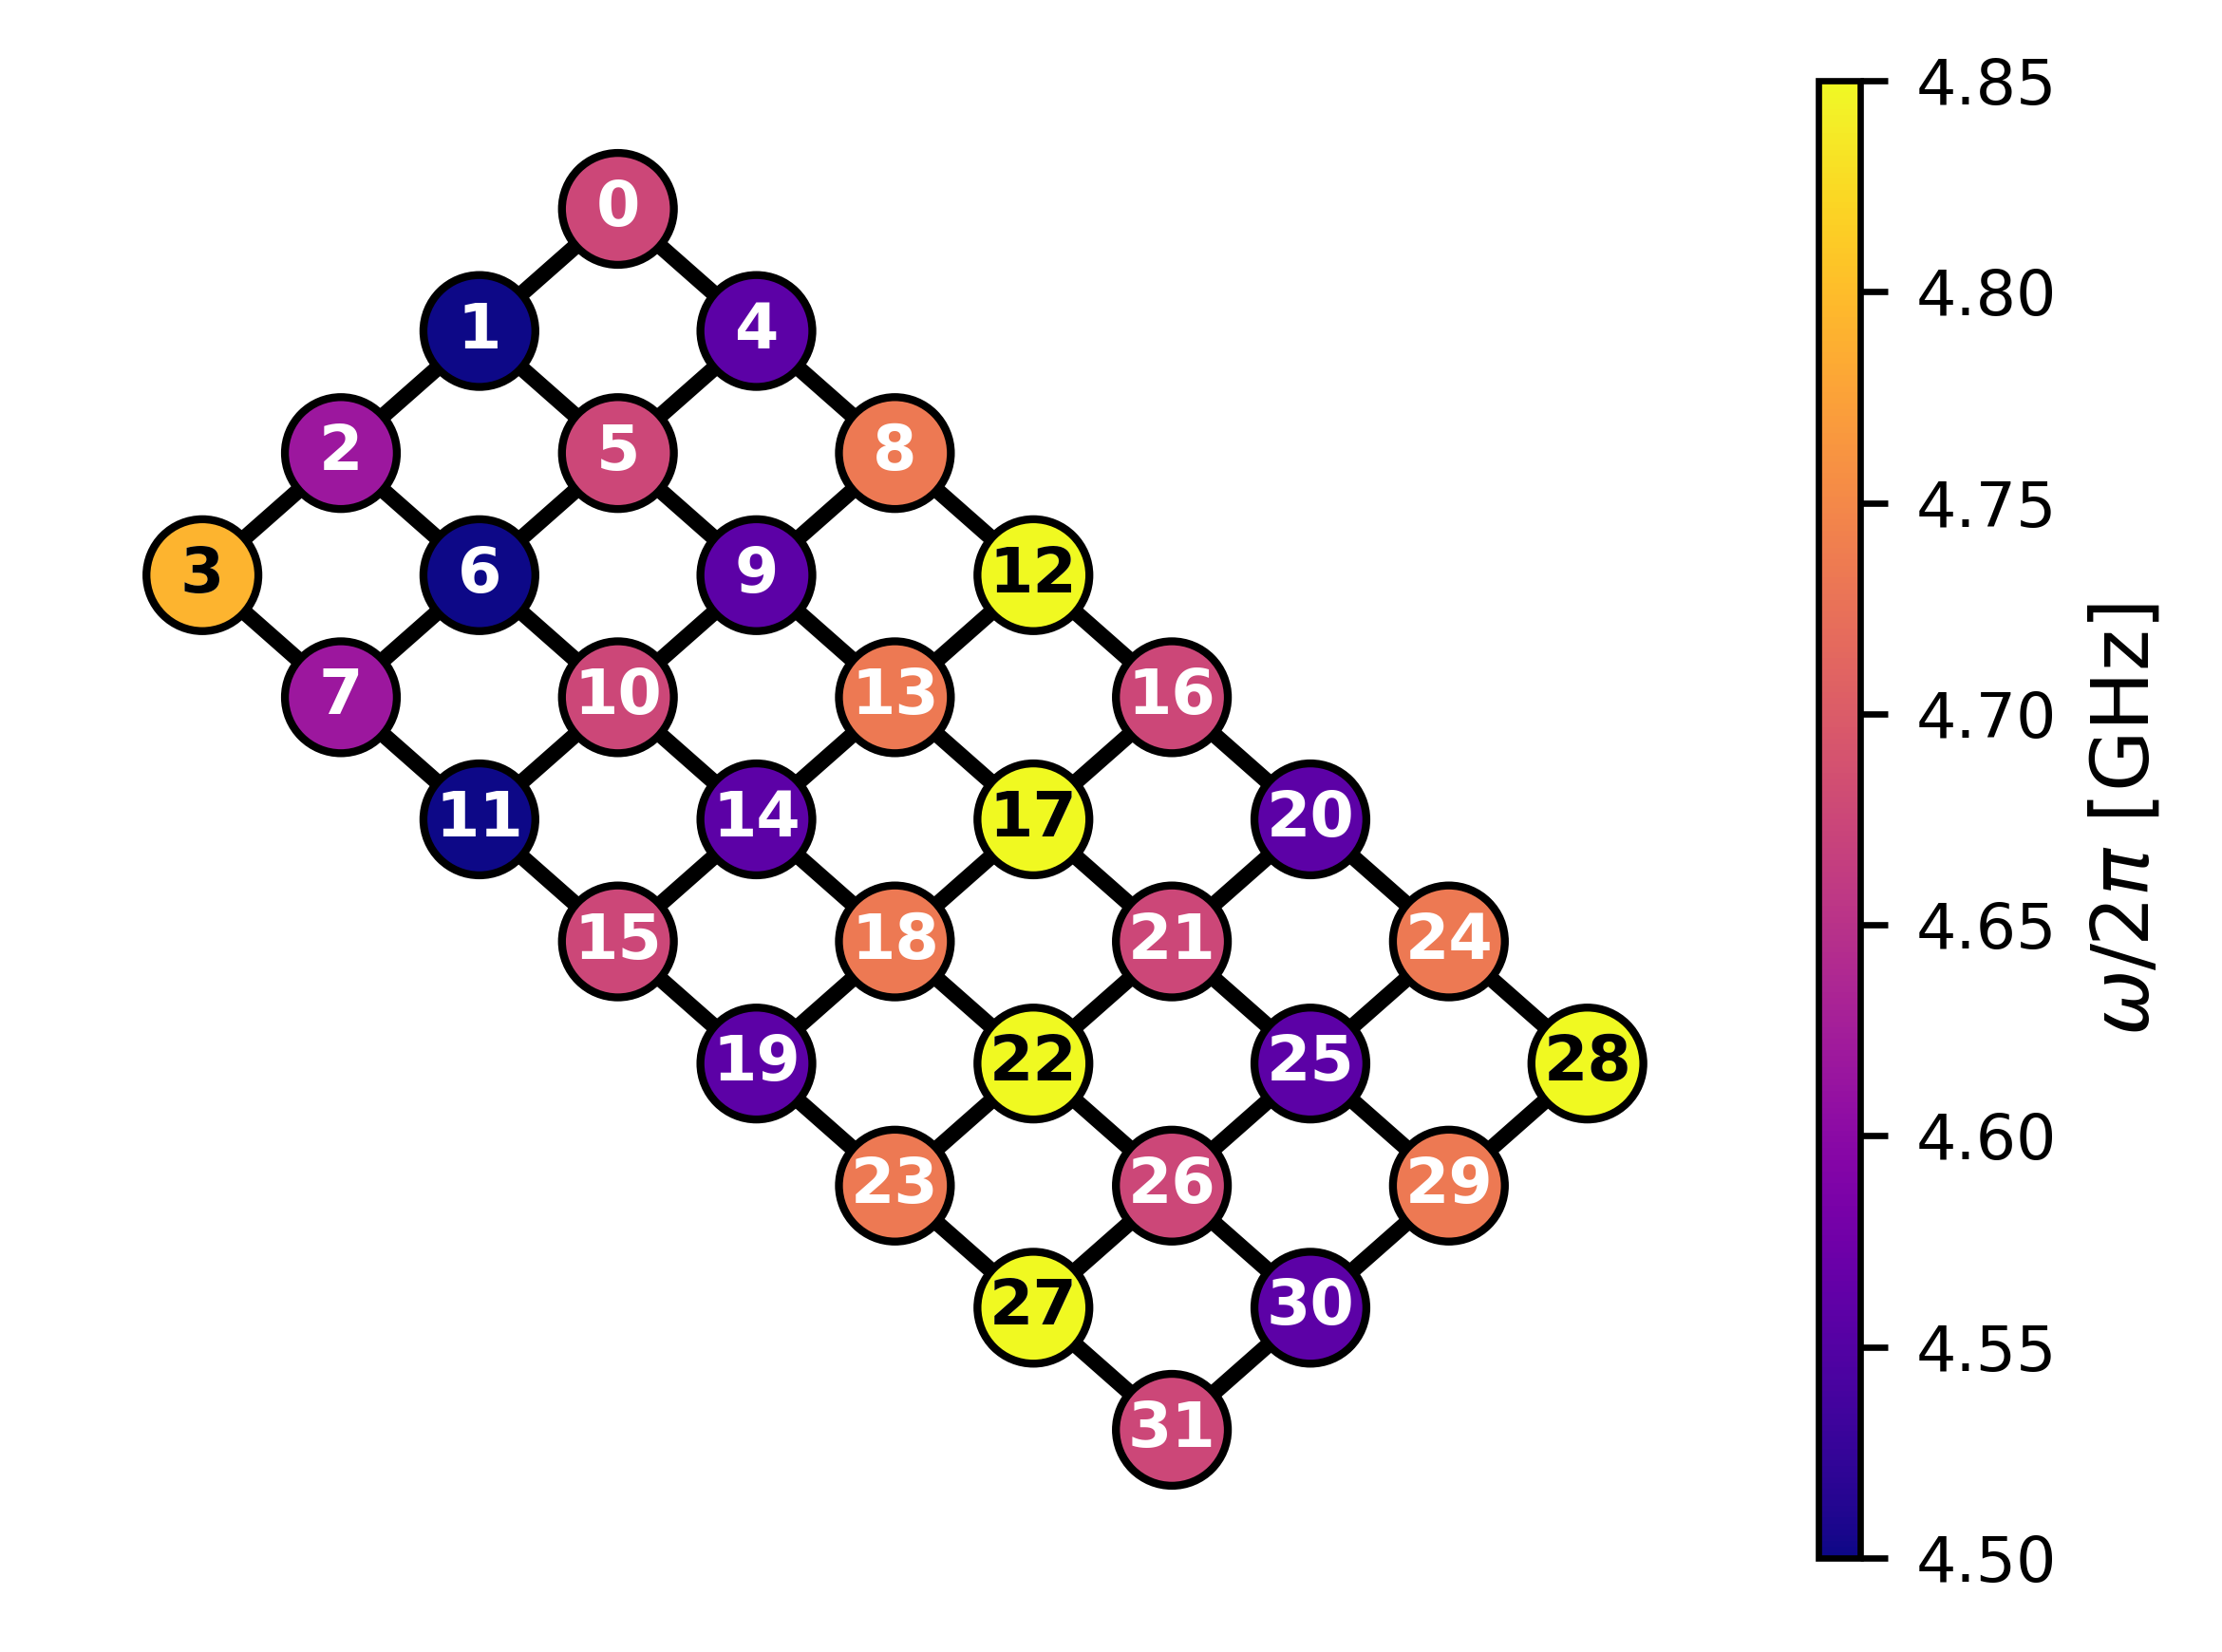

In [10]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

### Straightaway to the question about Peierls phase sign

Qubits 13th & 18th have plus sign detuning with respect to 14th <br>
The same sign of modulation phase in each experiment <br>
Result: 0 flux through plaquette

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    6.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    9.9s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   13.5s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   17.2s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   20.6s remaining:    5.1s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:   23.2s remaining:    1.9s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:   23.7s finished


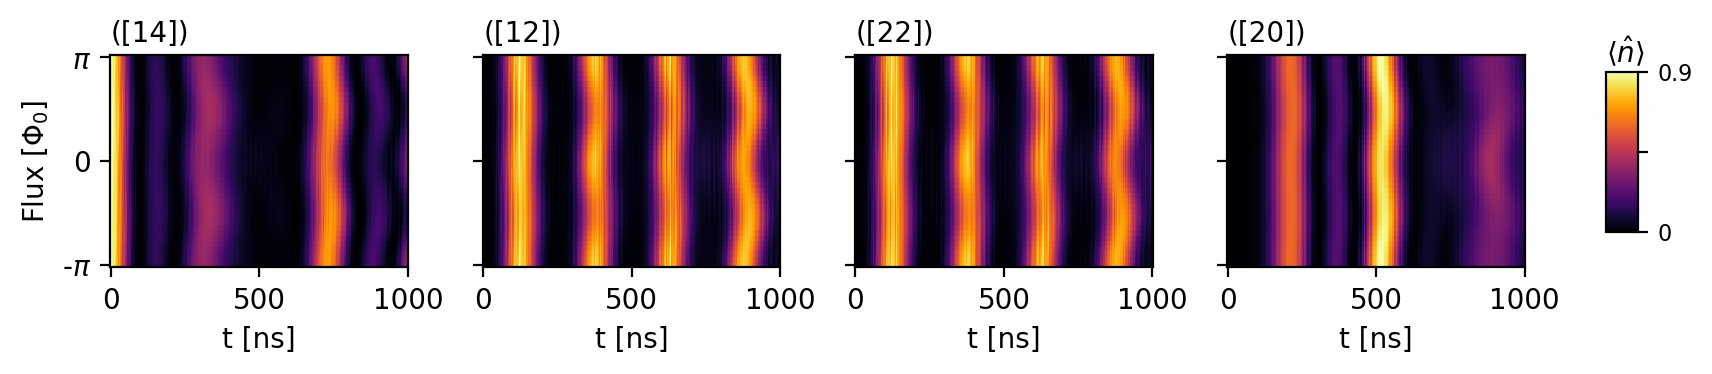

In [11]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(14,), (13, 18), (12, 22), (16, 21), (20,)],
                    'site_exc_id': [14], 'site_fock_number': [1], 'site_modul_id': [13, 18], 
                    'site_monitor_id_list': [[14], [12], [22], [20]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40), np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

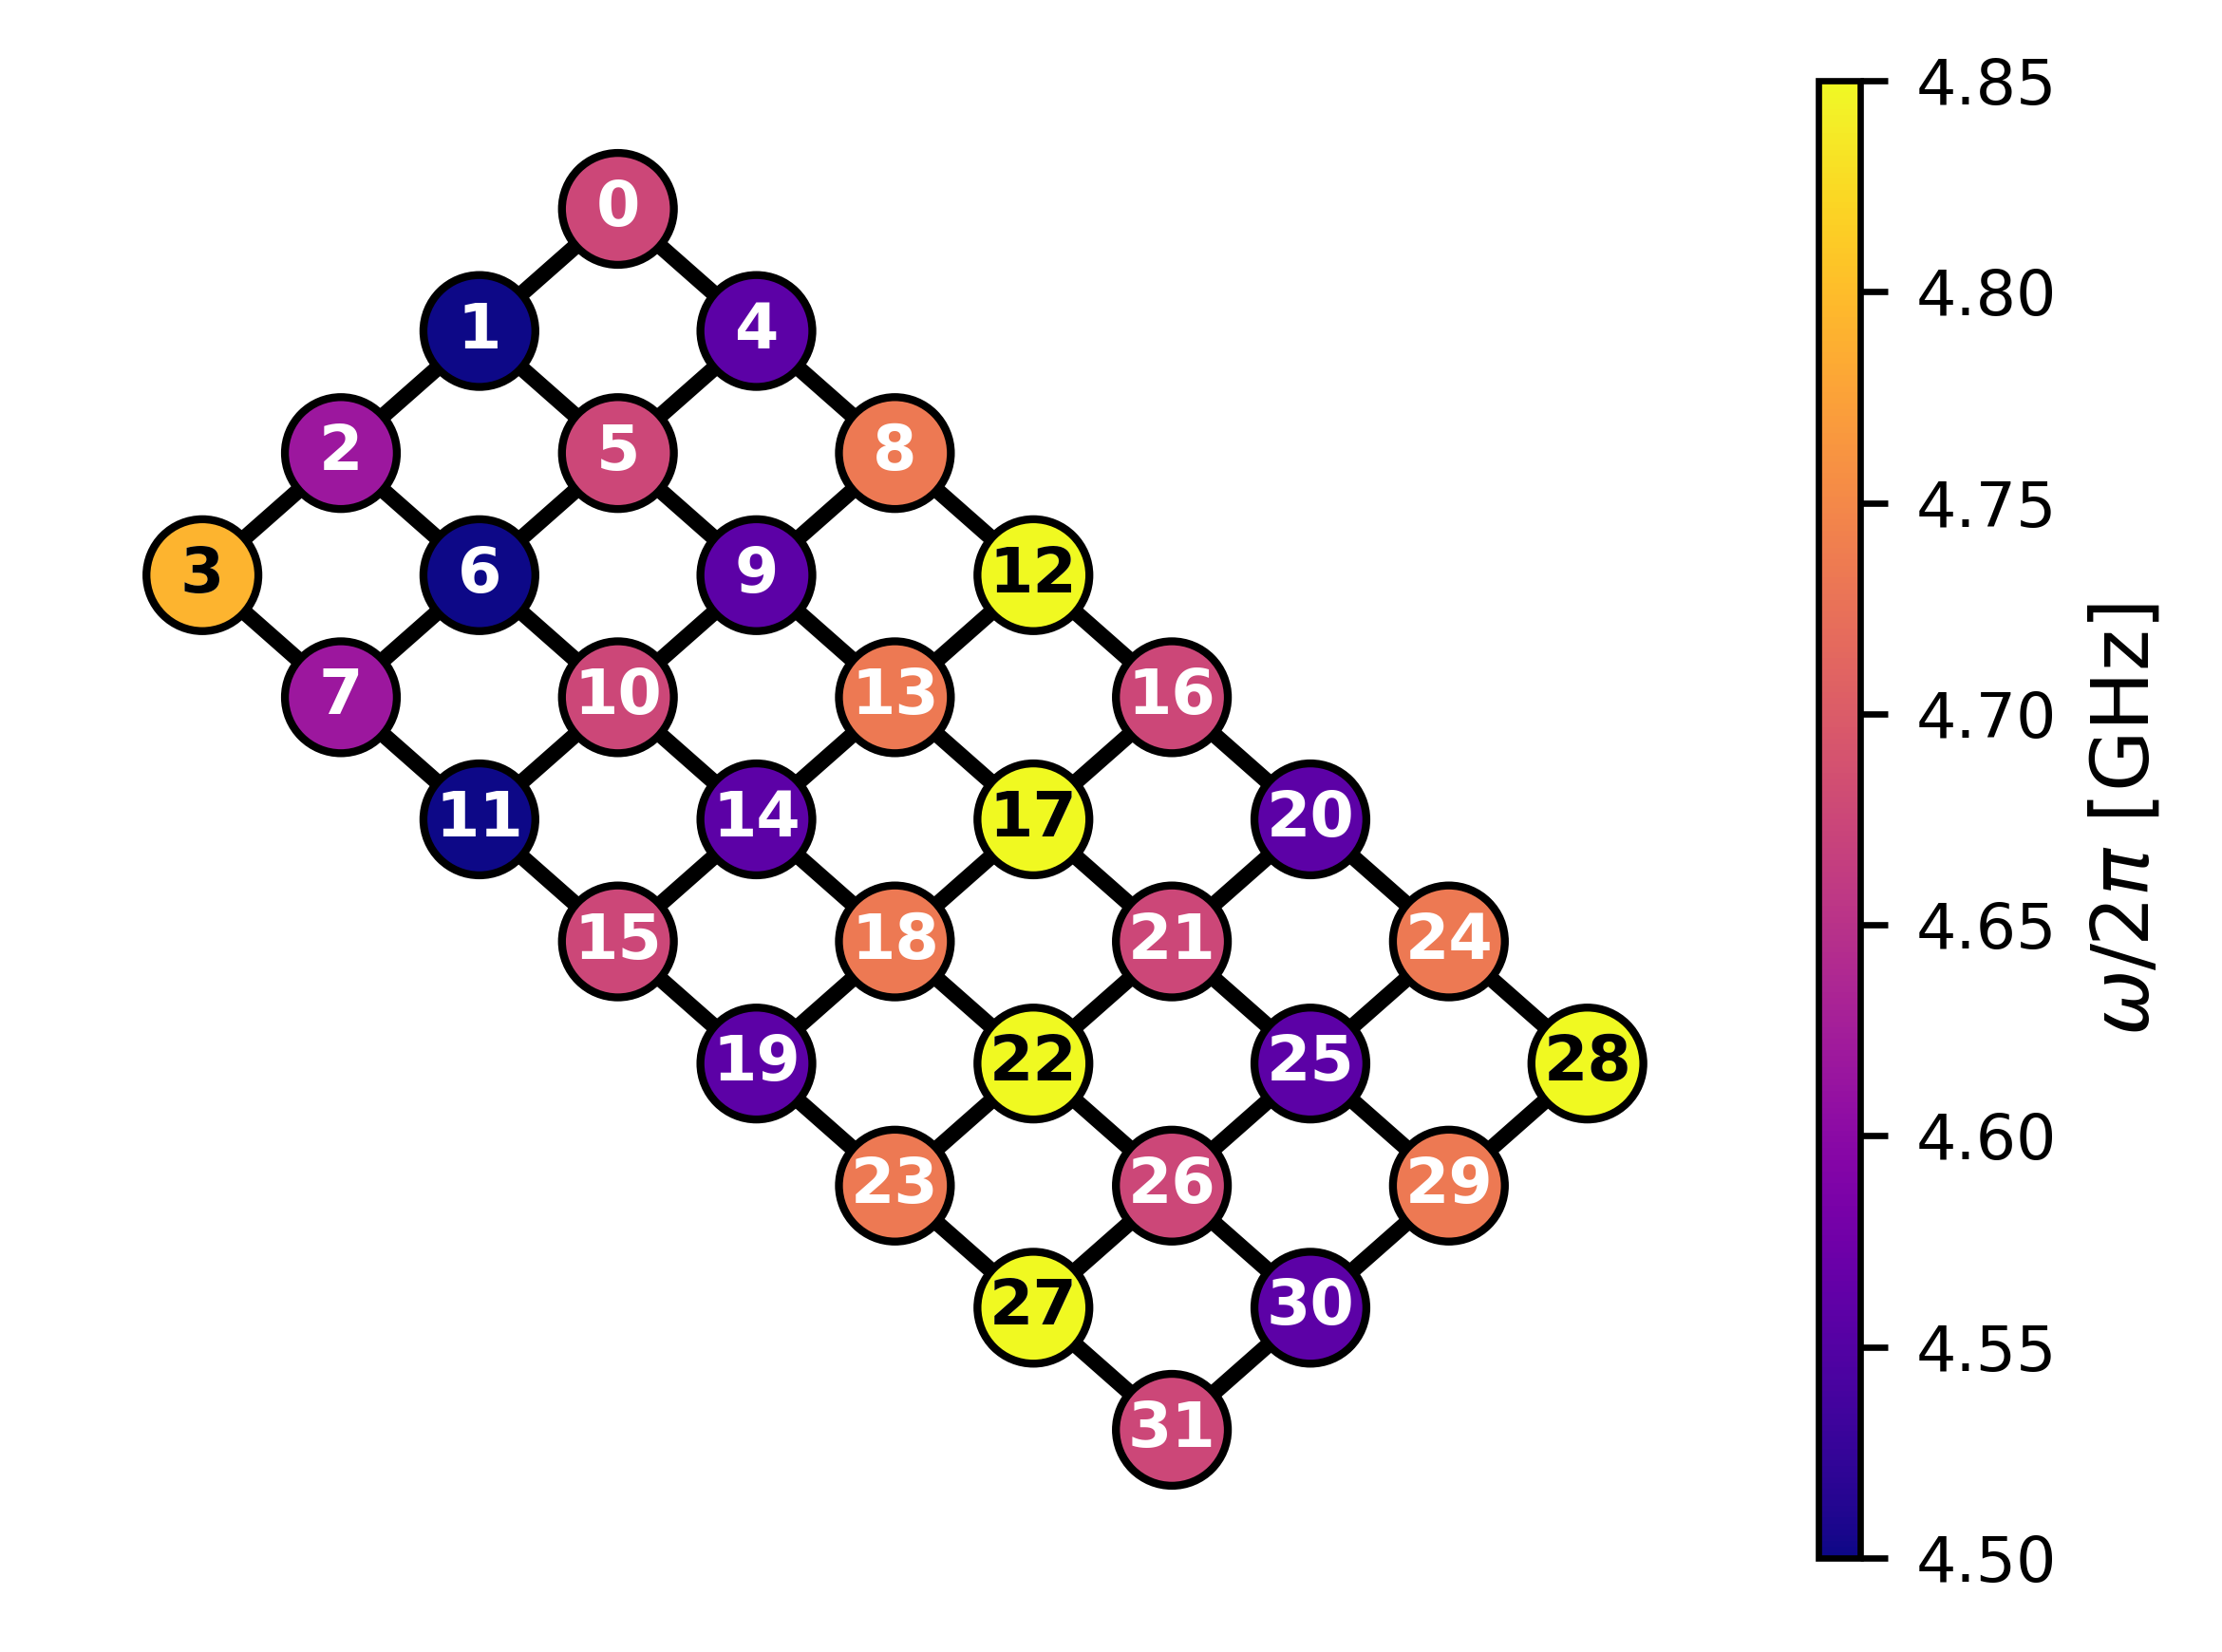

In [12]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

Qubits 16th & 18th have minus & plus sign detunings, respectively, with respect to 14th and 12th <br>
The same sign of modulation phase in each experiment <br>
Result: 0 flux through plaquette <br>

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    3.7s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    7.5s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   11.2s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   14.9s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   18.6s remaining:    4.7s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:   21.5s remaining:    1.7s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:   21.9s finished


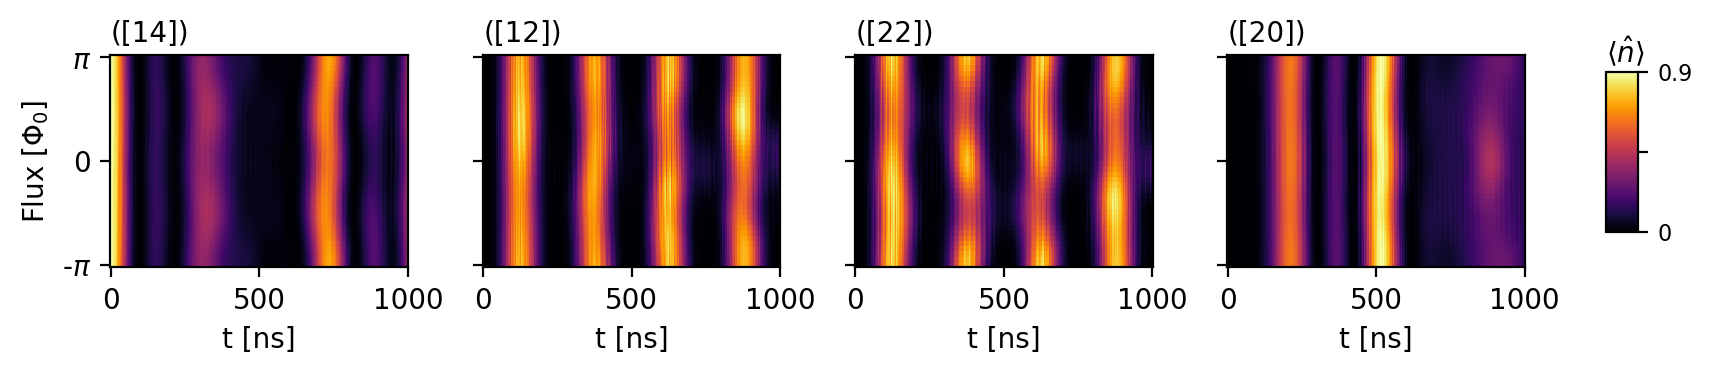

In [13]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(14,), (13, 18), (12, 22), (16, 21), (20,)],
                    'site_exc_id': [14], 'site_fock_number': [1], 'site_modul_id': [16, 18], 
                    'site_monitor_id_list': [[14], [12], [22], [20]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40), np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

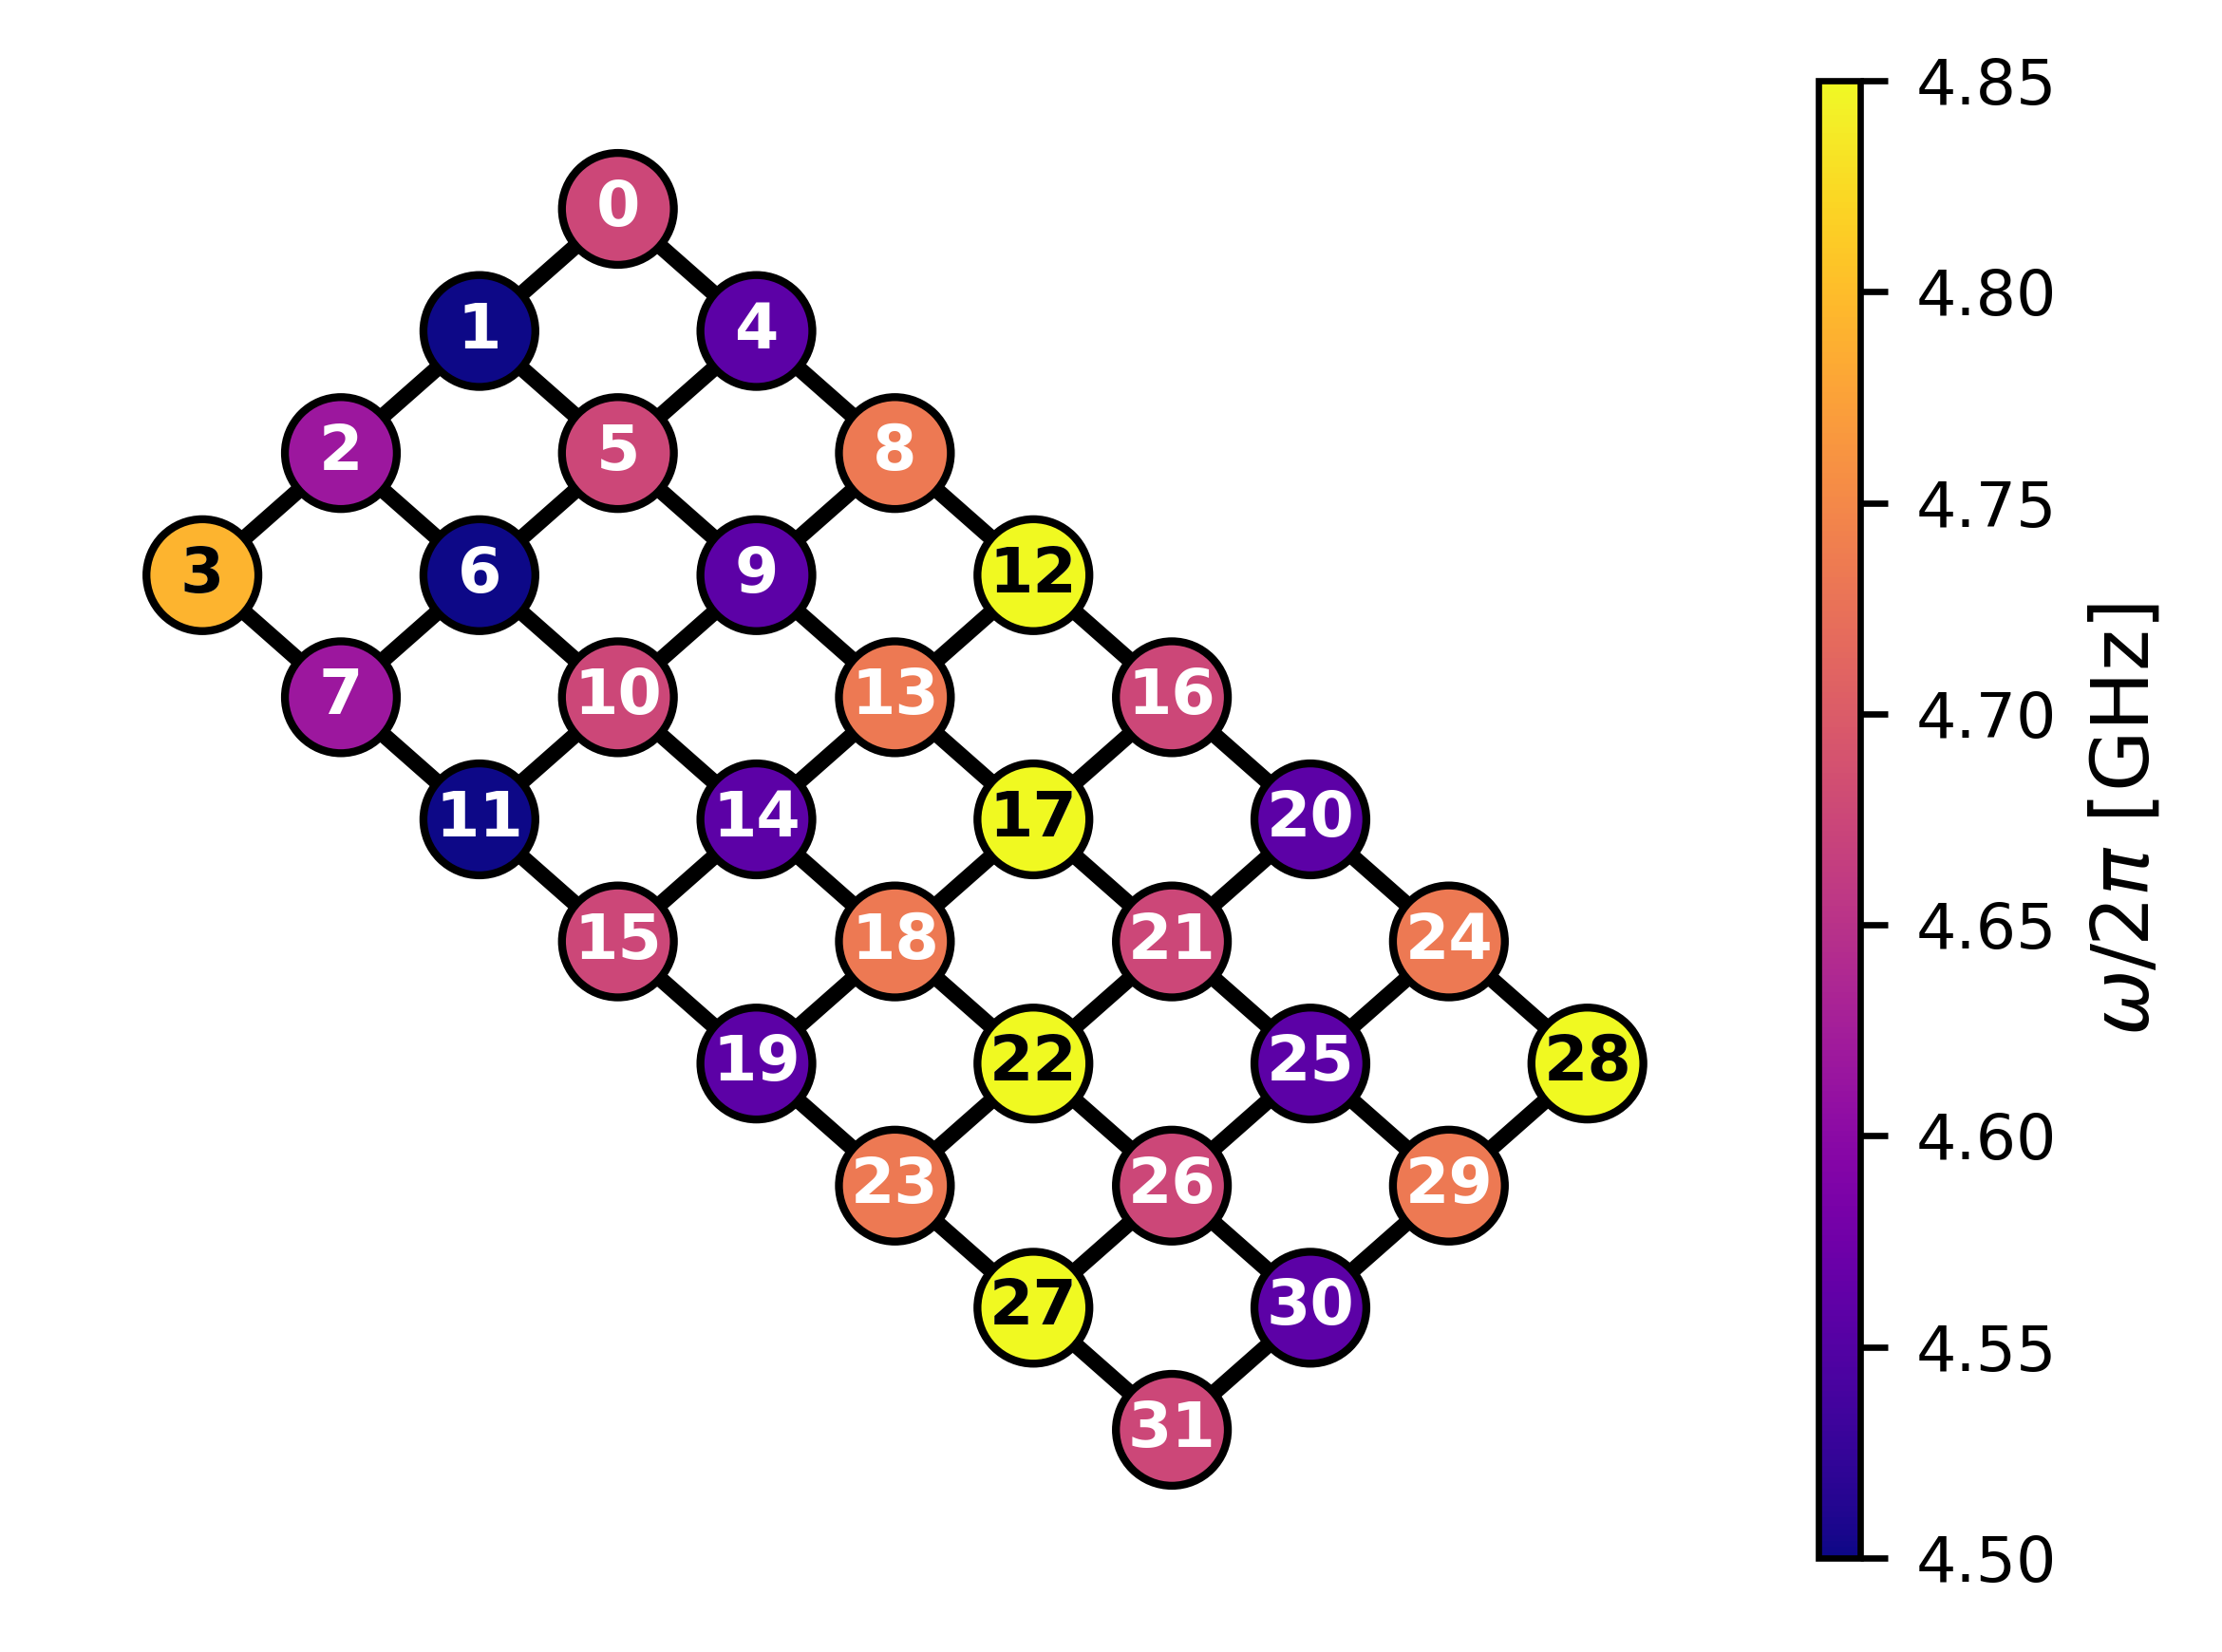

In [14]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

Qubits 16th & 18th have minus & plus sign detunings, respectively, with respect to 14th and 12th <br>
Different signs of modulation phases in each experiment <br>
Result: 2 * pi flux through plaquette <br>
Question: Does only sign of modulation phase matter?

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    3.8s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    7.5s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   11.1s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   15.1s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   18.8s remaining:    4.7s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:   21.9s remaining:    1.8s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:   22.2s finished


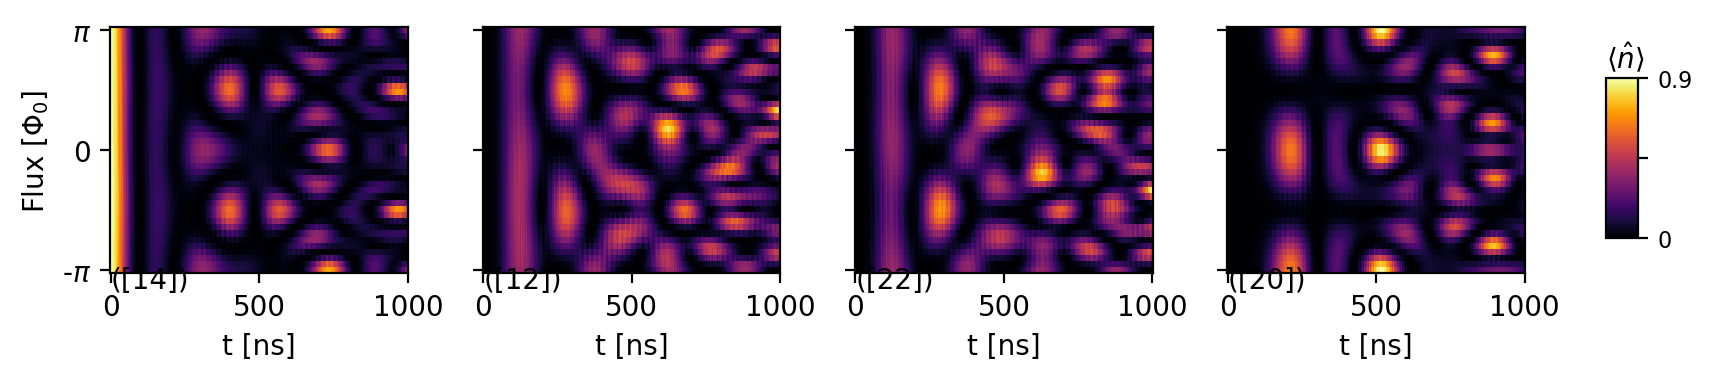

In [15]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(14,), (13, 18), (12, 22), (16, 21), (20,)],
                    'site_exc_id': [14], 'site_fock_number': [1], 'site_modul_id': [16, 18], 
                    'site_monitor_id_list': [[14], [12], [22], [20]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(pi, -pi, 40), np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 2x2 ring

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    4.6s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    7.1s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:    9.5s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   12.0s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   14.6s remaining:    3.6s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:   16.4s remaining:    1.3s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:   16.8s finished


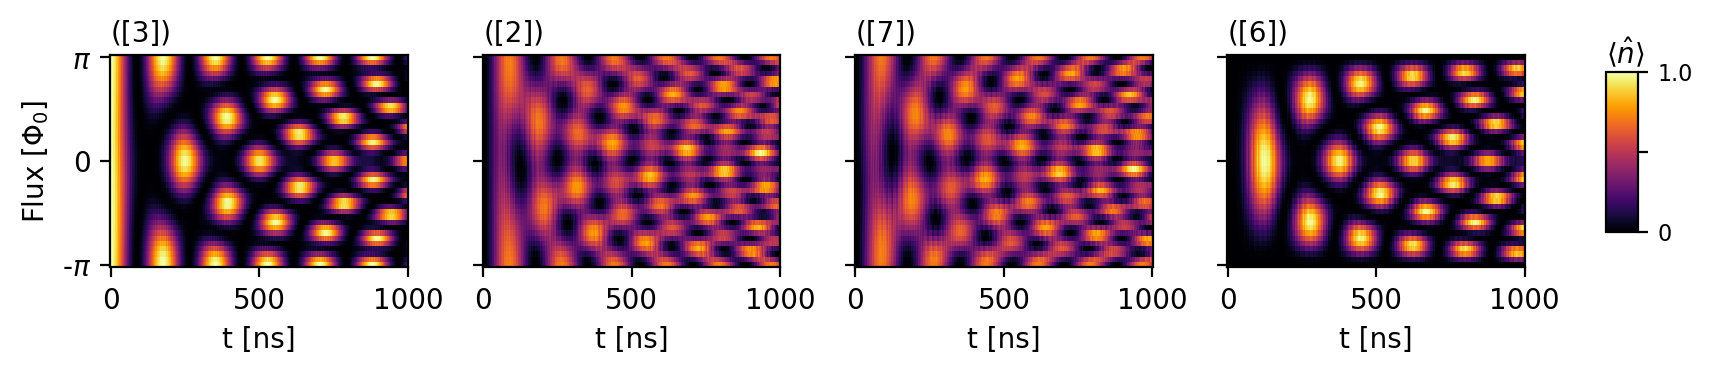

In [5]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(3,), (2, 7), (6,)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': [7], 
                    'site_monitor_id_list': [[3], [2], [7], [6]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 3x3 ring

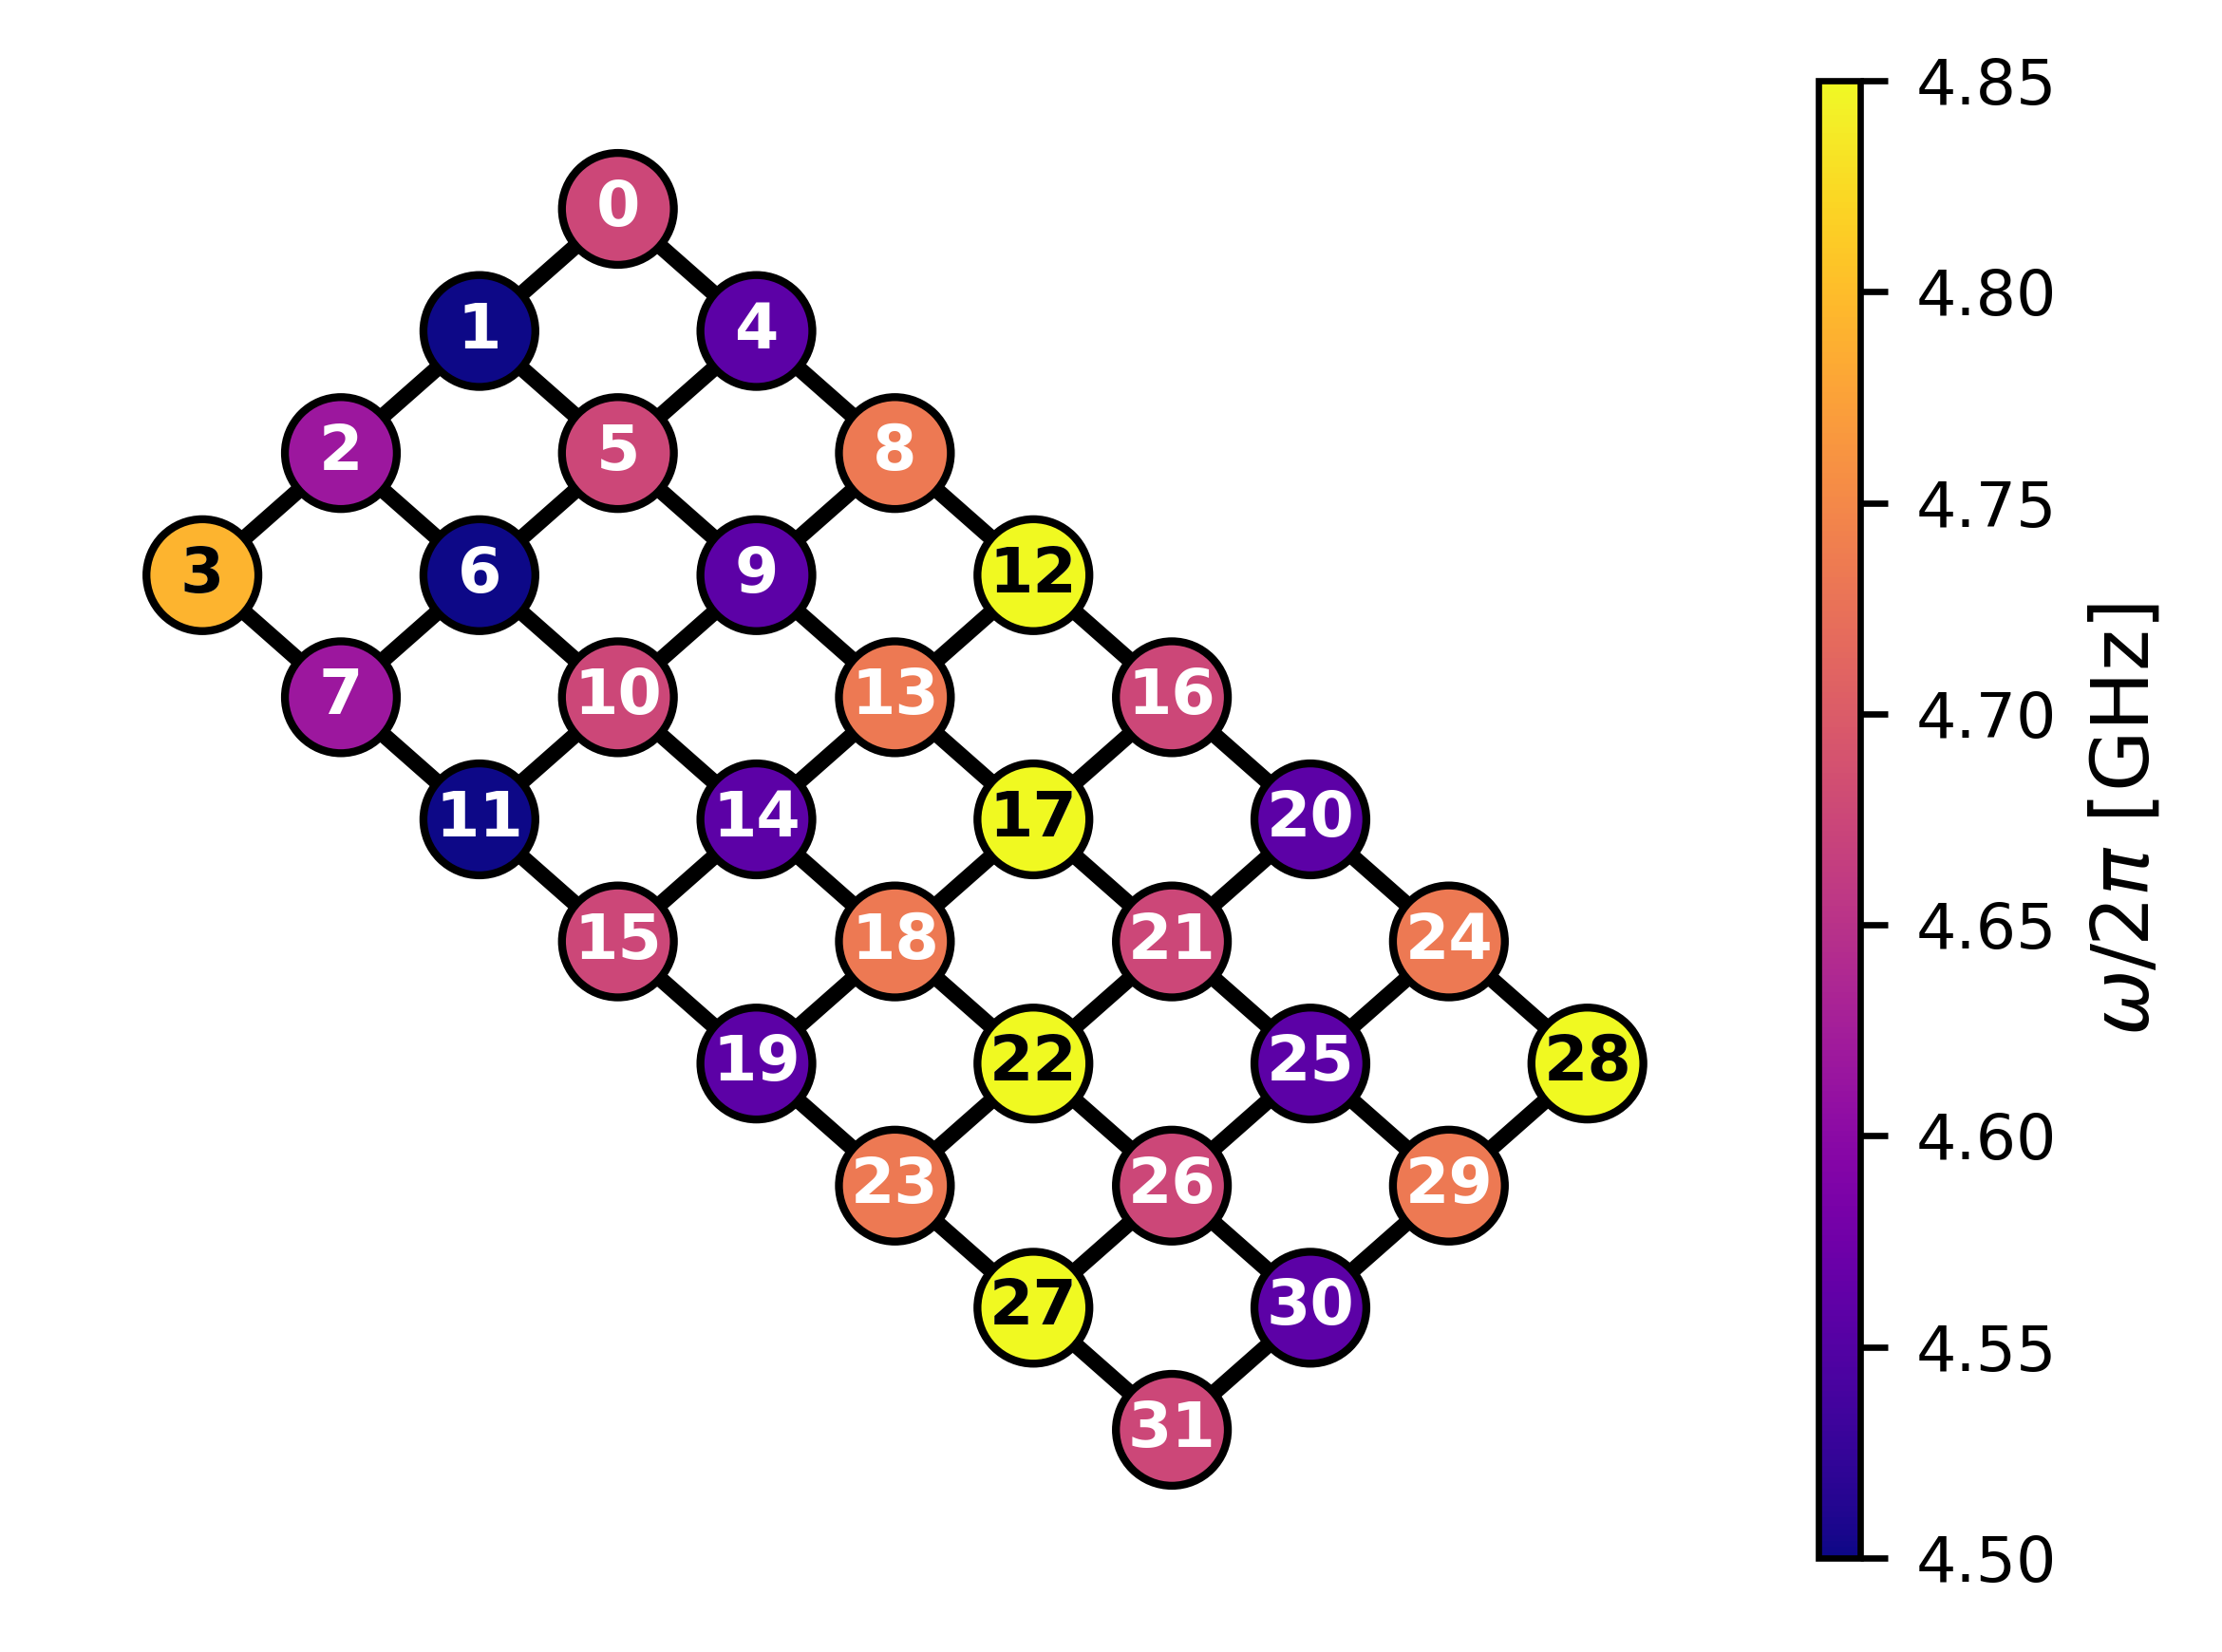

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   11.5s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   21.1s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   31.2s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   42.2s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:   52.9s remaining:   13.2s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  1.0min remaining:    5.0s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  1.0min finished


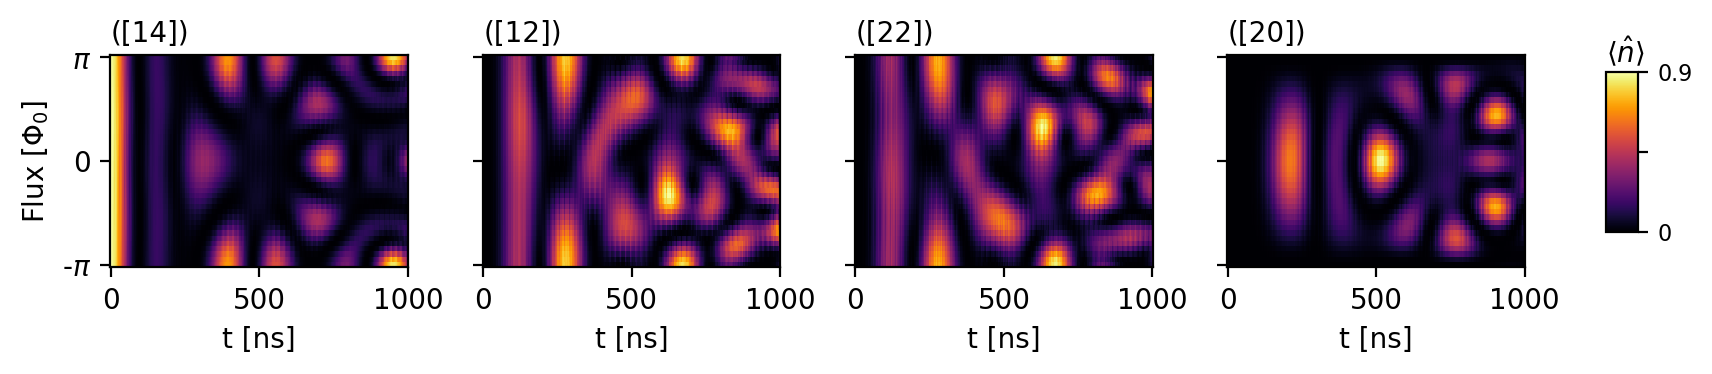

In [5]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(14,), (13, 18), (12, 22), (16, 21), (20,)],
                    'site_exc_id': [14], 'site_fock_number': [1], 'site_modul_id': [18], 
                    'site_monitor_id_list': [[14], [12], [22], [20]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1e3, int(1e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 4x4 ring

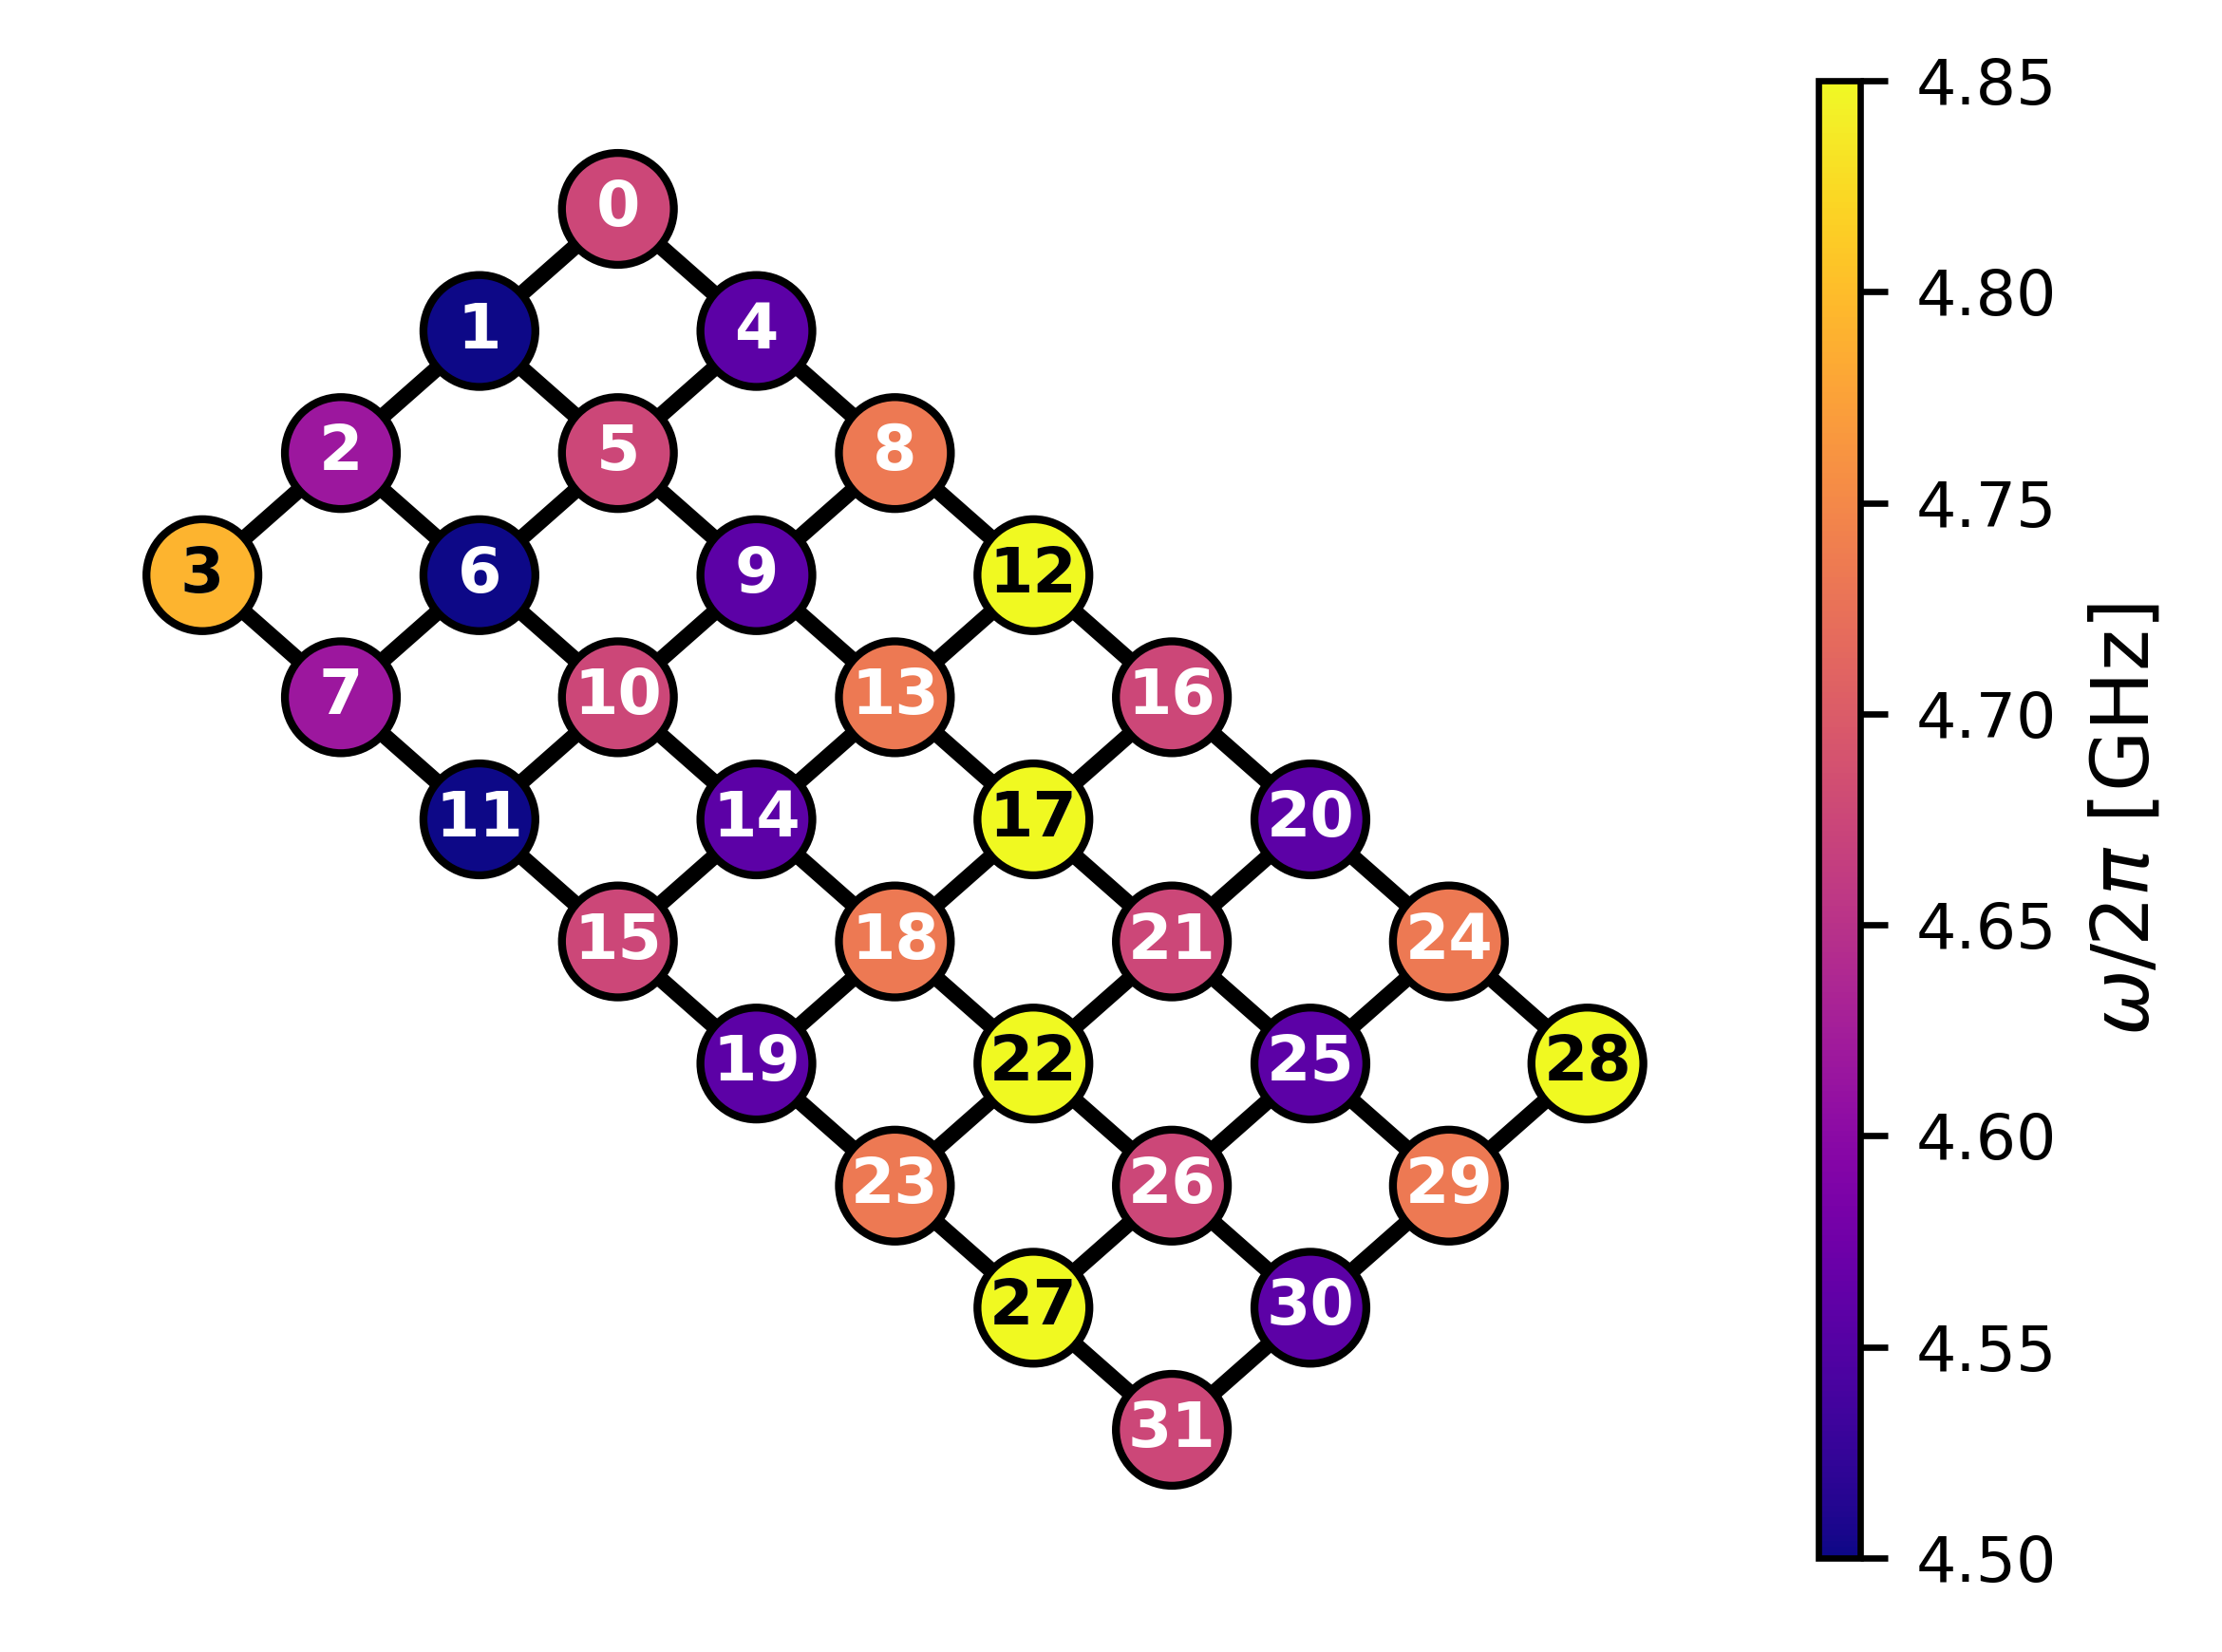

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   11.7s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   24.3s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   37.7s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:   52.3s
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:  1.1min remaining:   16.4s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  1.3min remaining:    6.1s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  1.3min finished


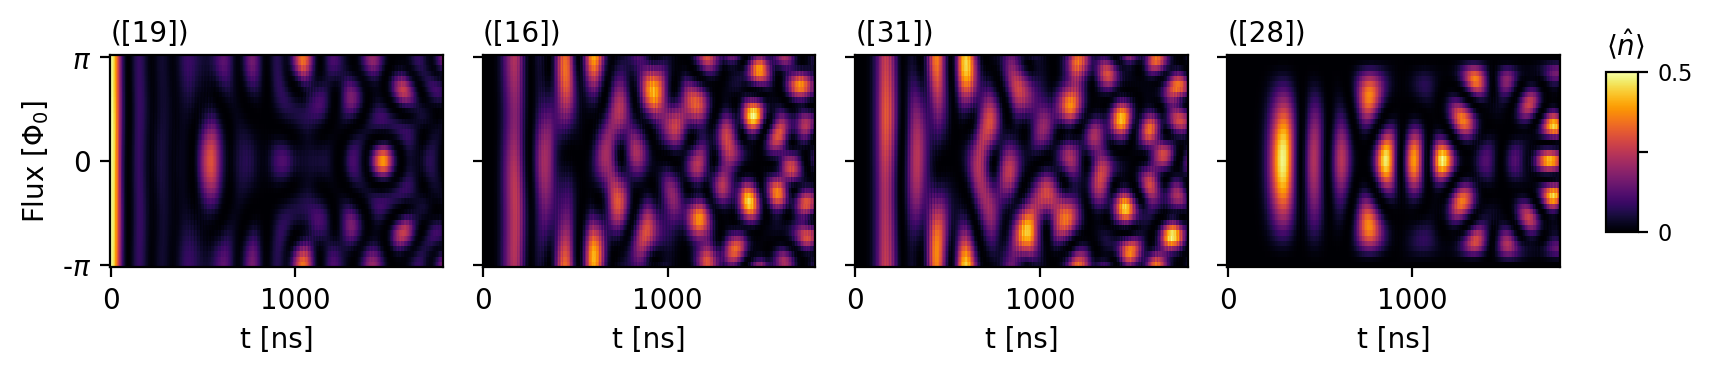

In [6]:
experiment_config_base = {'launch_code': 1,

                    'chosen_sites': [(19,), (18, 23), (17, 27), (16, 31), (20, 30), (24, 29), (28,)],
                    'site_exc_id': [19], 'site_fock_number': [1], 'site_modul_id': [18], 
                    'site_monitor_id_list': [[19], [16], [31], [28]], 'site_monitor_fock_numbers': [[1], [1], [1], [1]],

                    'operating_time_points': np.linspace(0, 1.8e3, int(1.8e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 14q in a ring

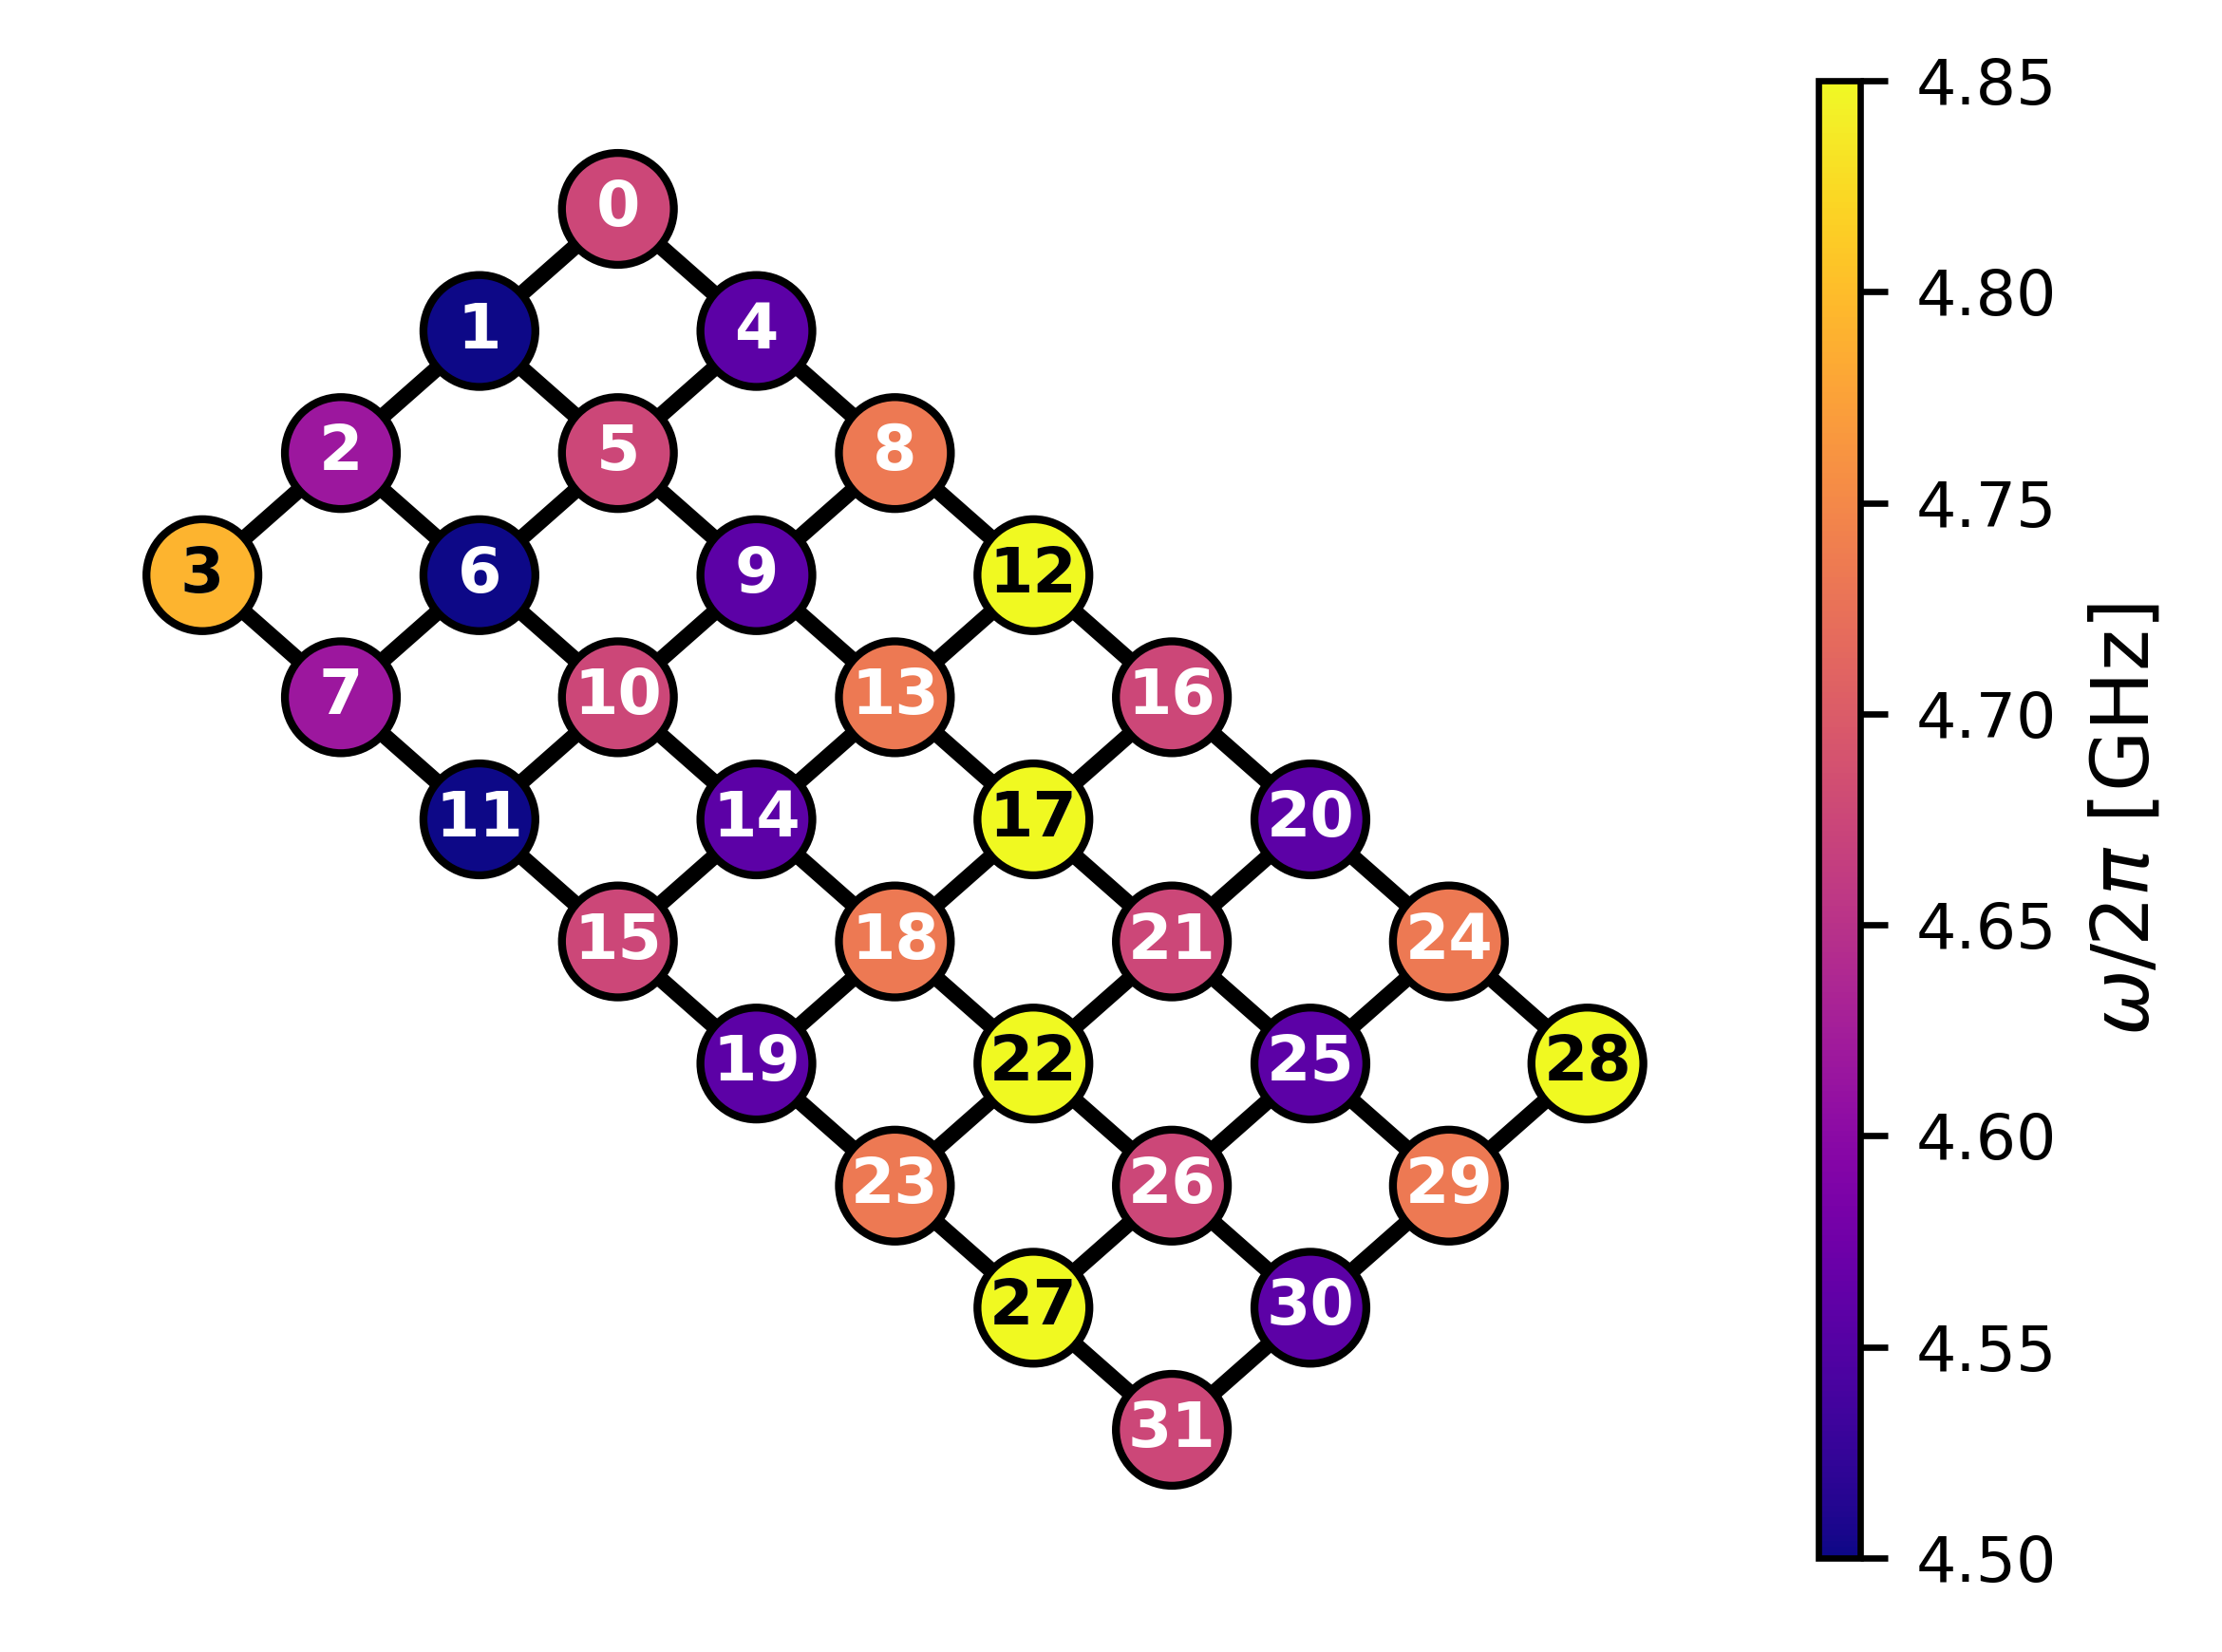

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   16.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   33.6s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:   52.3s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  1.2min
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:  1.5min remaining:   23.1s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  1.8min remaining:    8.7s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  1.8min finished


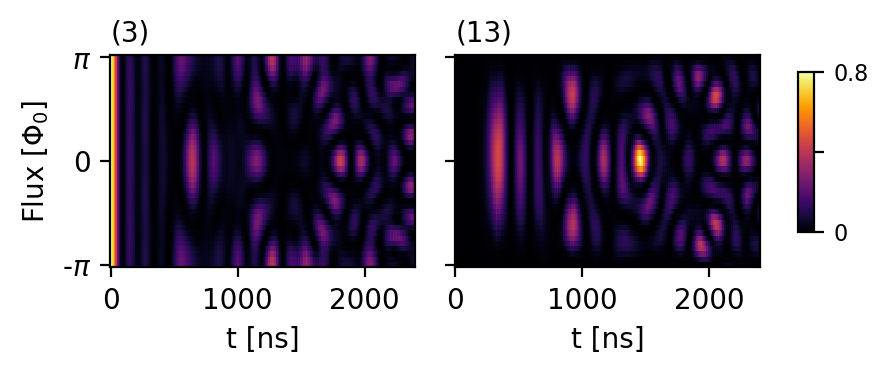

In [ ]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(3,), (2, 7), (1, 11), (0, 15), (4, 9, 19), (8, 13, 18), (17,)],
                    'site_exc_id': [3], 'site_modul_id': 11, 
                    'site_monitor_id_list': [3, 13],

                    'operating_time_points': np.linspace(0, 2.4e3, int(2.4e3 + 1)), # ns
                    'phi_list': np.linspace(-pi, pi, 40), 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

#### 22q in a ring

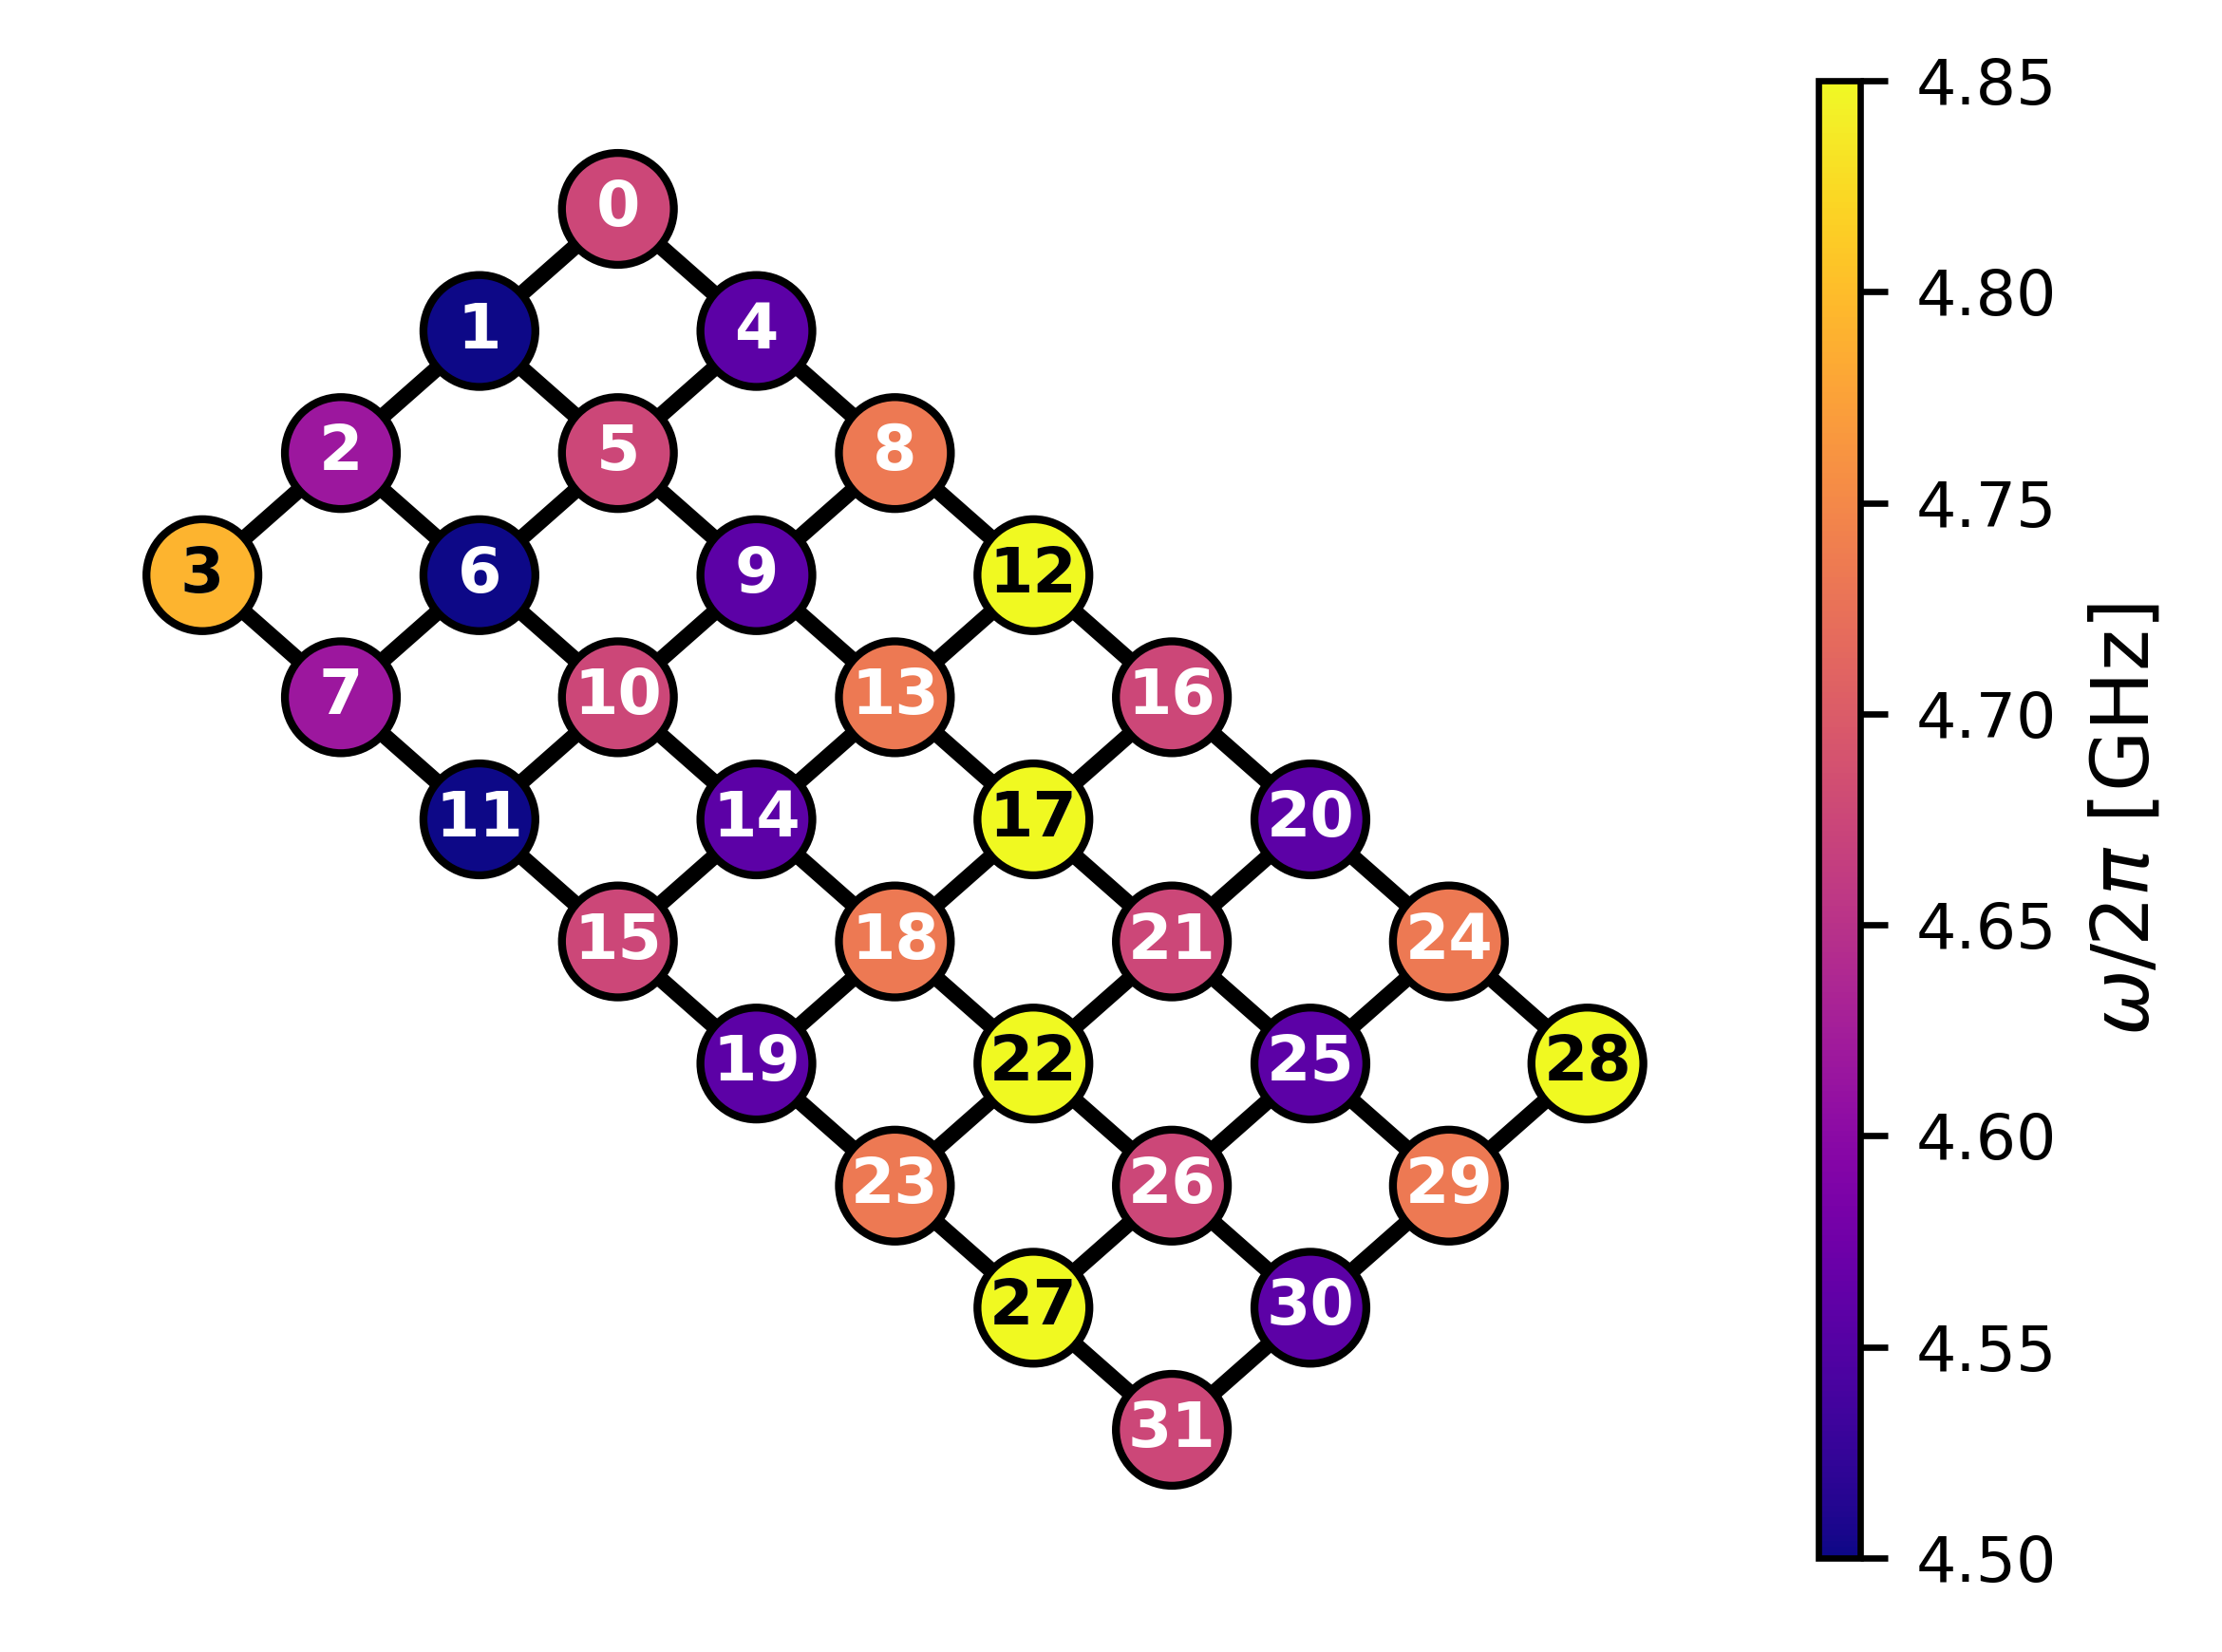

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   39.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  1.3min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  2.0min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  2.8min
[Parallel(n_jobs=7)]: Done  32 out of  40 | elapsed:  3.4min remaining:   51.5s
[Parallel(n_jobs=7)]: Done  37 out of  40 | elapsed:  3.9min remaining:   18.9s
[Parallel(n_jobs=7)]: Done  40 out of  40 | elapsed:  4.0min finished


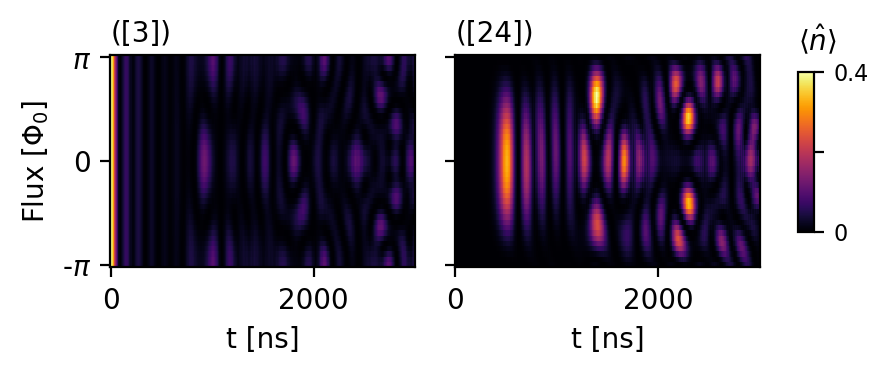

In [7]:
experiment_config_base = {'launch_code': 1,
                          
                    'chosen_sites': [(3,), (2, 7), (1, 11), (0, 15), (4, 9, 19), (8, 13, 23), (17, 27), (16, 31), (20, 25, 30), (24, 29)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': [16], 
                    'site_monitor_id_list': [[3], [24]], 'site_monitor_fock_numbers': [[1], [1]],

                    'operating_time_points': np.linspace(0, 3e3, int(3e3 + 1)), # ns
                    'phi_list': [np.linspace(-pi, pi, 40)], 'ef_strength_list': None,

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

### Faraday's law

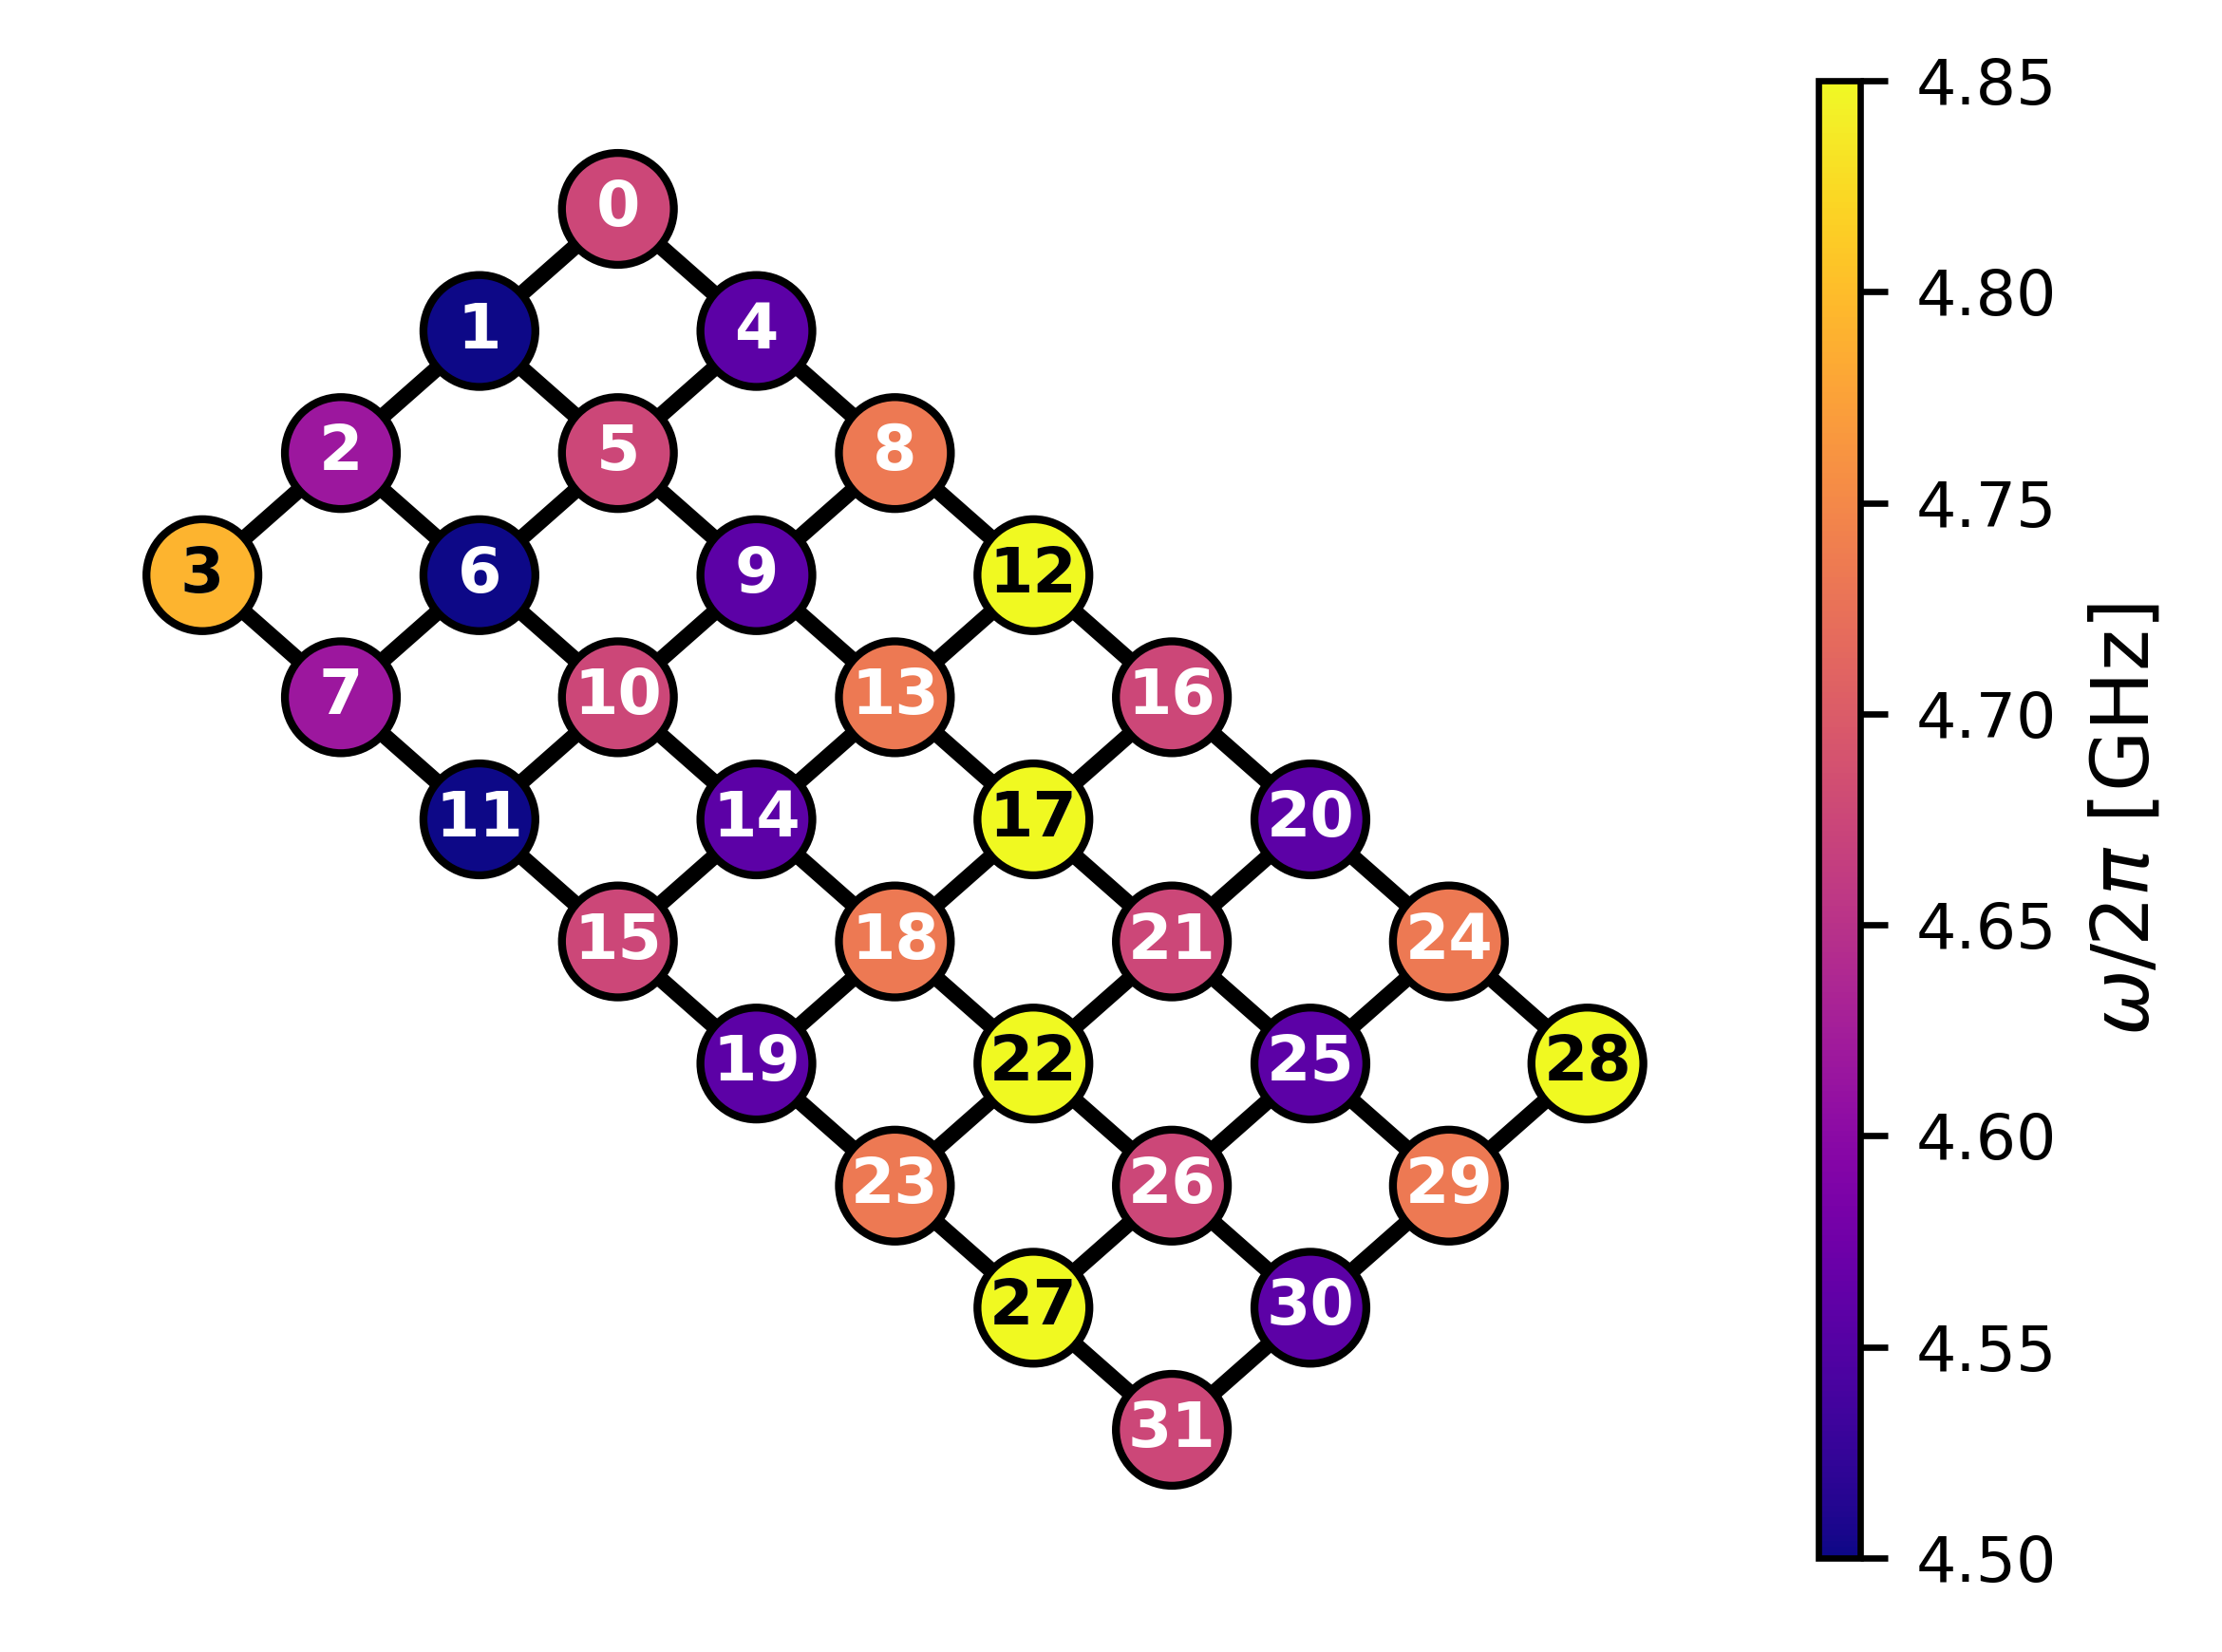

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

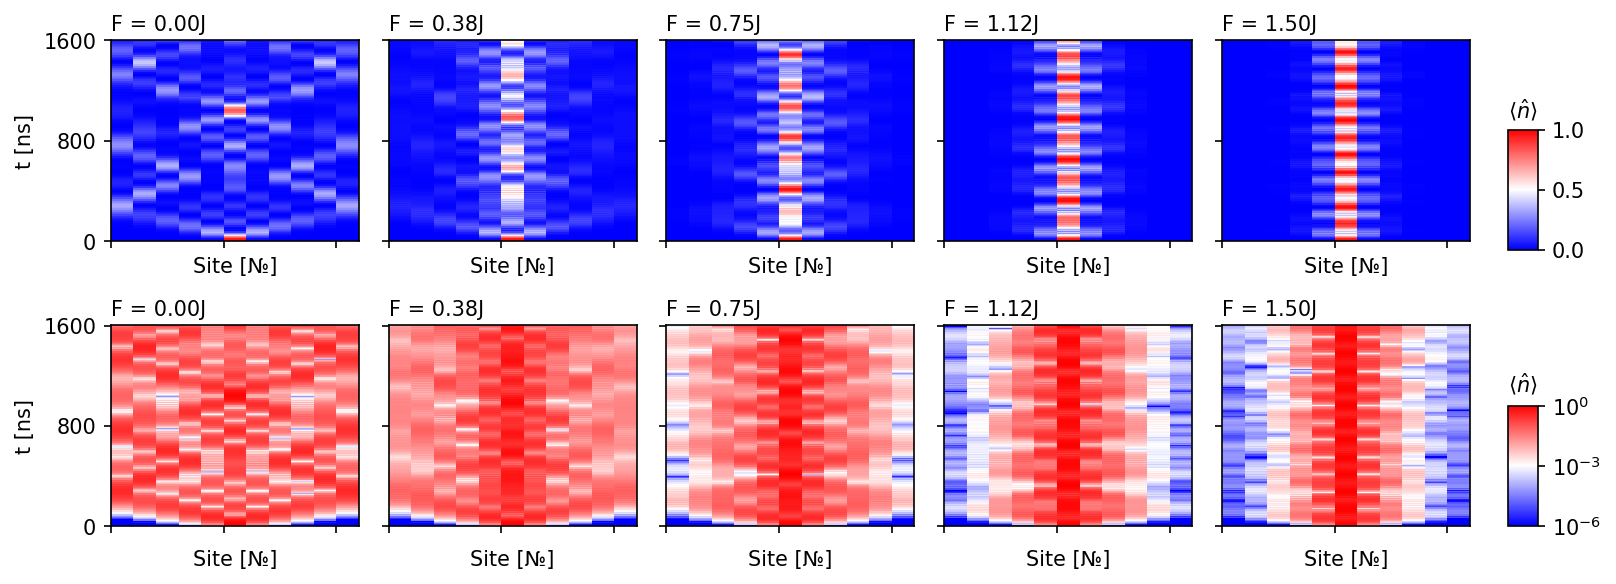

In [8]:
experiment_config_base = {'launch_code': 2,

                    'chosen_sites': [(15,), (14, 19), (13, 23), (12, 27), (16, 26), (20, 25)],
                    'site_exc_id': [15], 'site_fock_number': [1], 'site_modul_id': None,
                    'site_monitor_id_list': [20, 16, 12, 13, 14, 15, 19, 23, 27, 26, 25],

                    'operating_time_points': np.linspace(0, 16e2, int(16e2 + 1)), # ns
                    'phi_list': None, 'ef_strength_list': np.linspace(0, 1.5, 5),

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

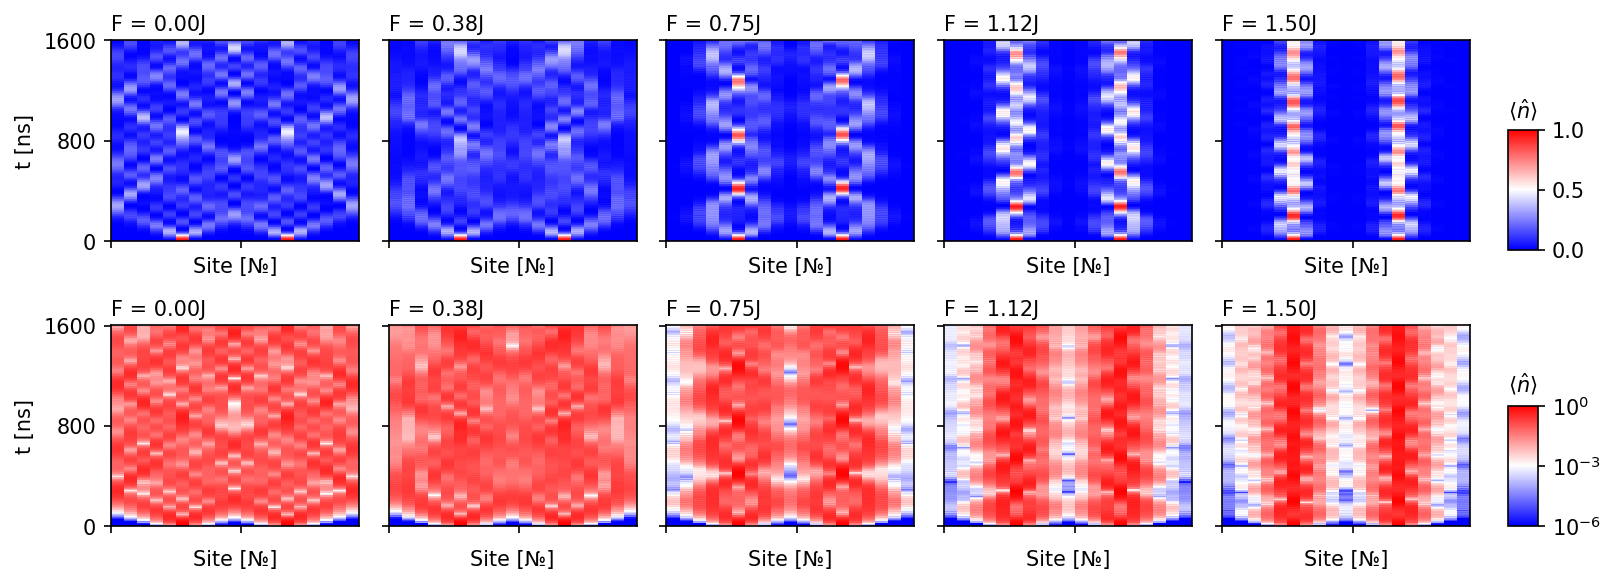

In [4]:
experiment_config_base = {'launch_code': 2,

                    'chosen_sites': [(3,), (2, 7), (1, 11), (5, 15), (9, 14), (8, 18), (12, 22), (16, 26), (20, 30), (24, 29)],
                    'site_exc_id': [9, 14], 'site_fock_number': [1, 1], 'site_modul_id': None,
                    'site_monitor_id_list': [24, 20, 16, 12, 8, 9, 5, 1, 2, 3, 7, 11, 15, 14, 18, 22, 26, 30, 29],

                    'operating_time_points': np.linspace(0, 16e2, int(16e2 + 1)), # ns
                    'phi_list': None, 'ef_strength_list': np.linspace(0, 1.5, 5),

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

- If there is asymmetry in how many qubits with frequency that is the frequency of initial excited qubit on the left and on the right, then excitation tends to localize in each of such qubit partially with increasing e-field <br>
- for two excitations that are initialized symmetrical regarding center of the chain it seems like there is different influence of the field on left and right part of the chain

Giving layout of dc freqs of qubits it is clear that if we start with excitation on 7th qubit then with high enough el field excitation swaps between 7th & 2nd qubit cuz their dc freqs & driving signals coincide

### Hall effect

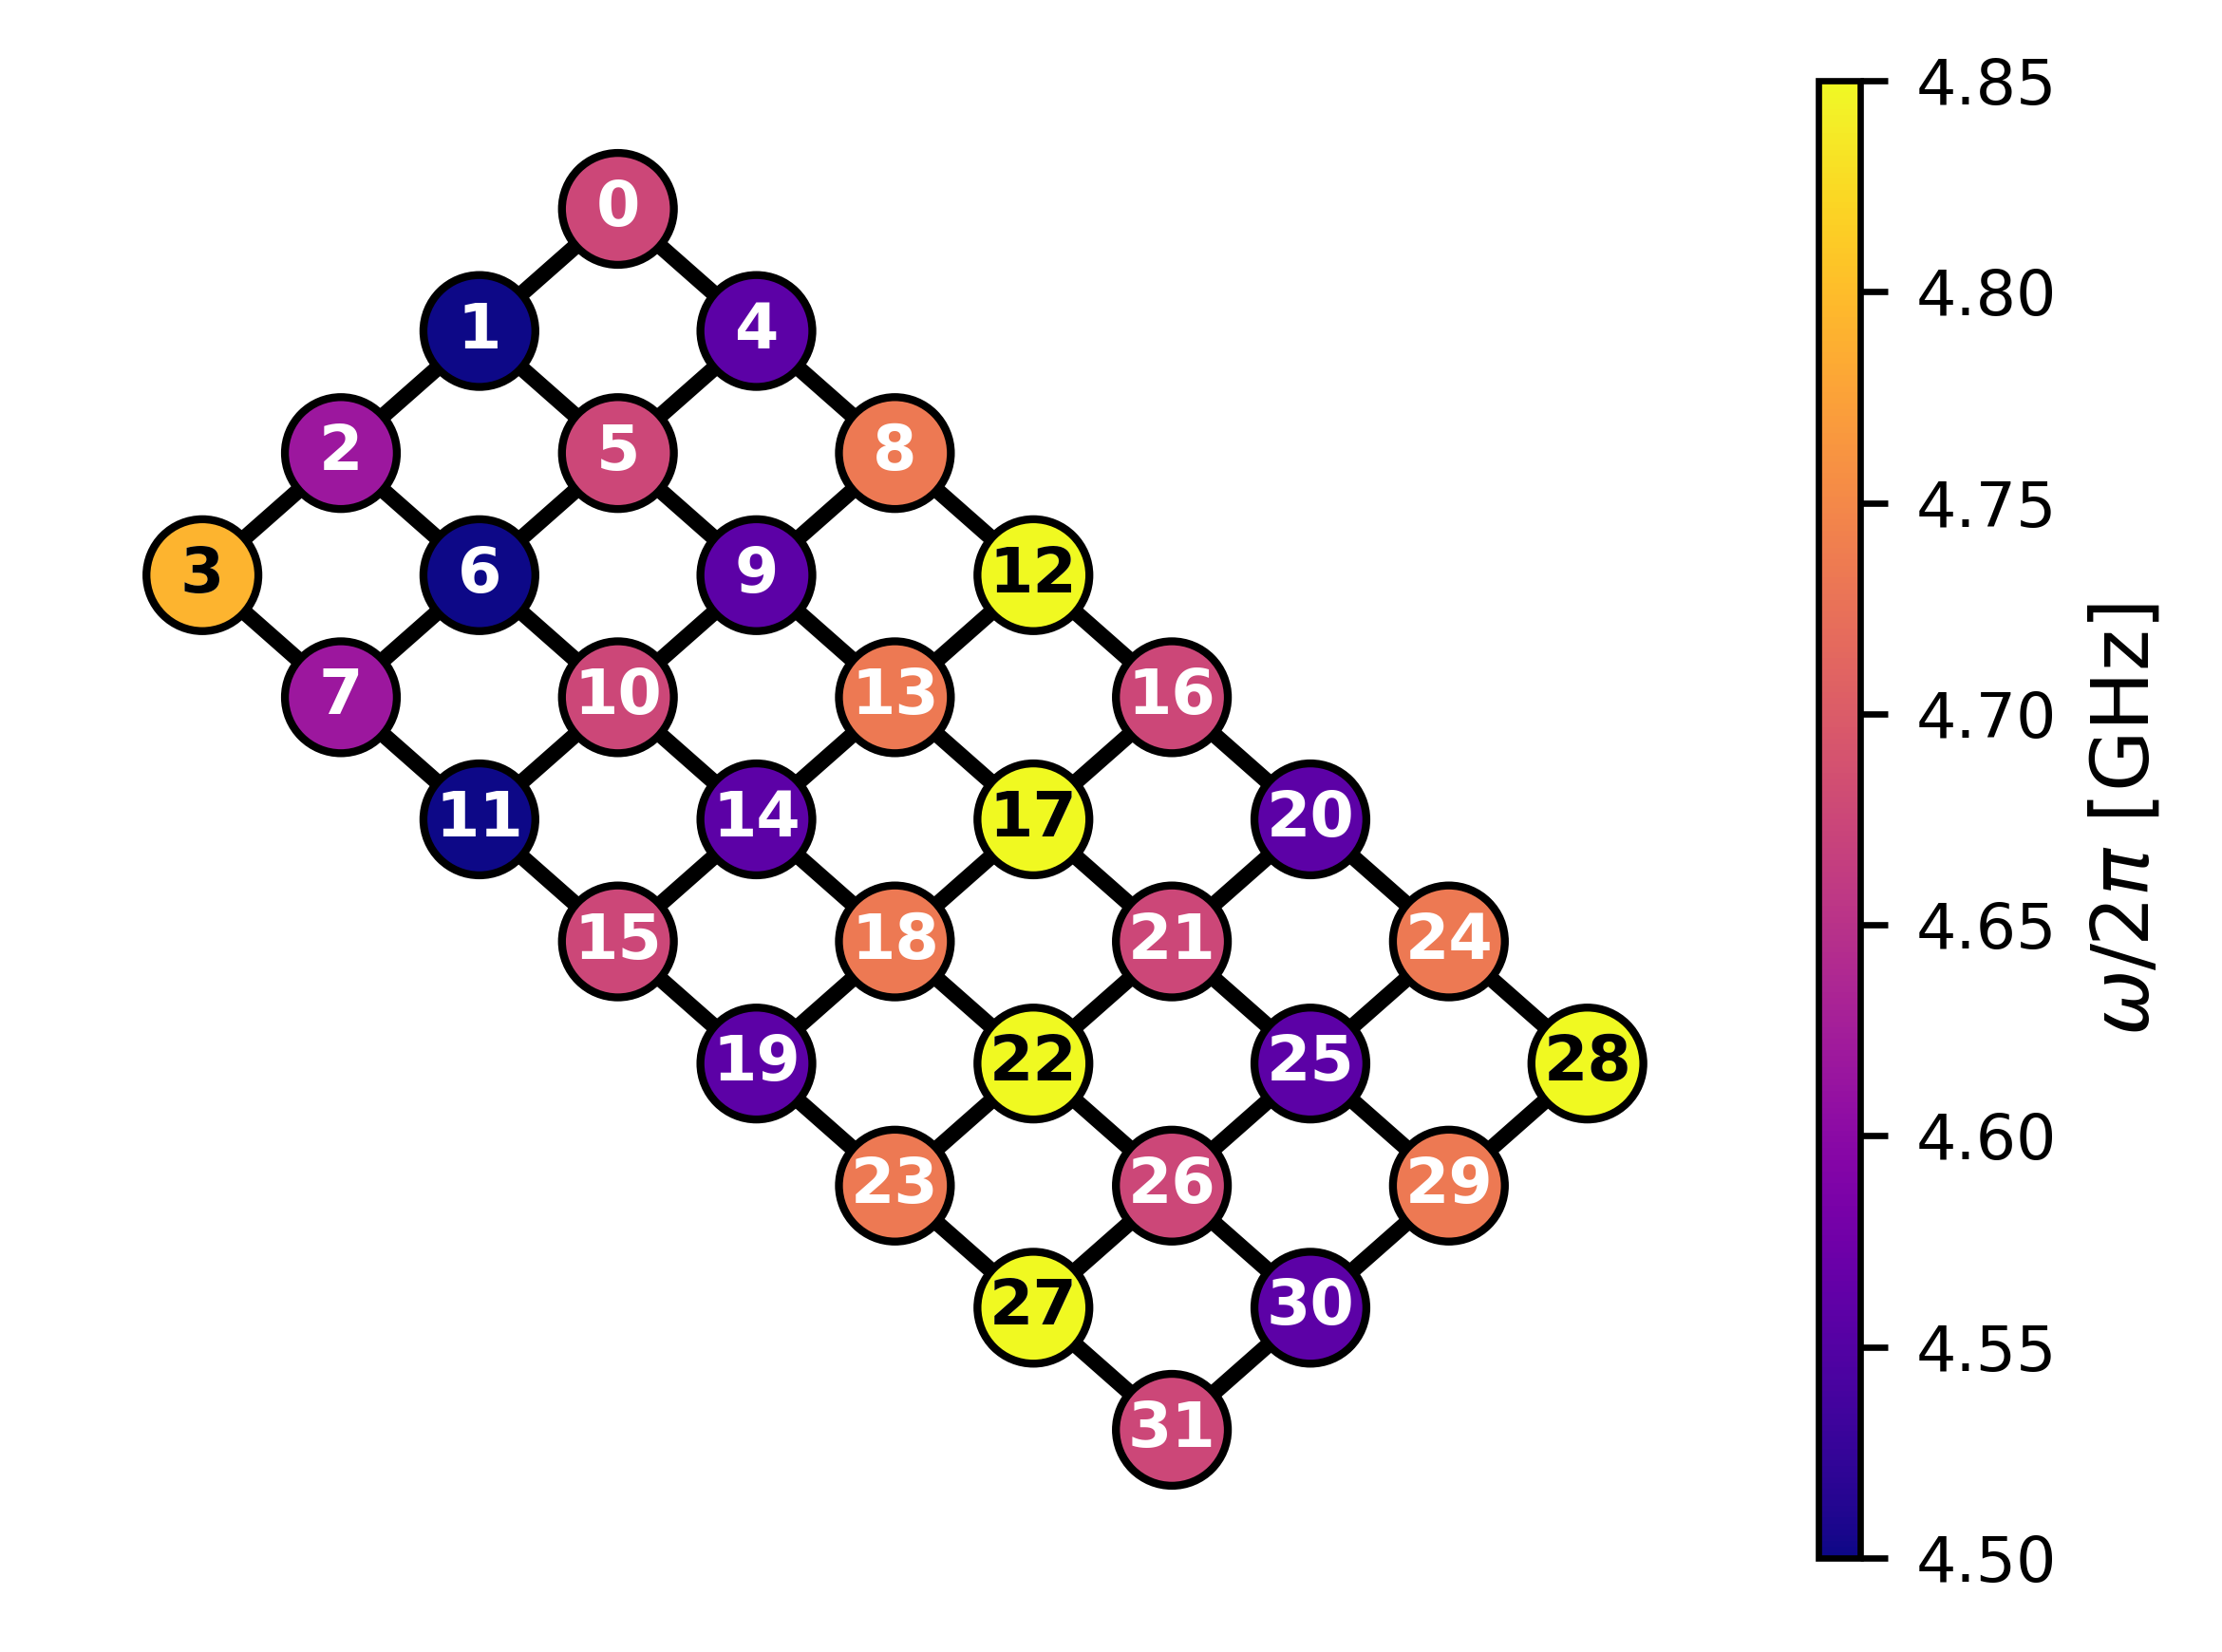

In [ ]:
display(Image(filename="Pictures/layout-32q.png", width=700, height=700))

#### Particle dynamics

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 out of  11 | elapsed:    1.3s remaining:    2.3s
[Parallel(n_jobs=7)]: Done   7 out of  11 | elapsed:    1.4s remaining:    0.8s
[Parallel(n_jobs=7)]: Done  11 out of  11 | elapsed:    2.2s finished


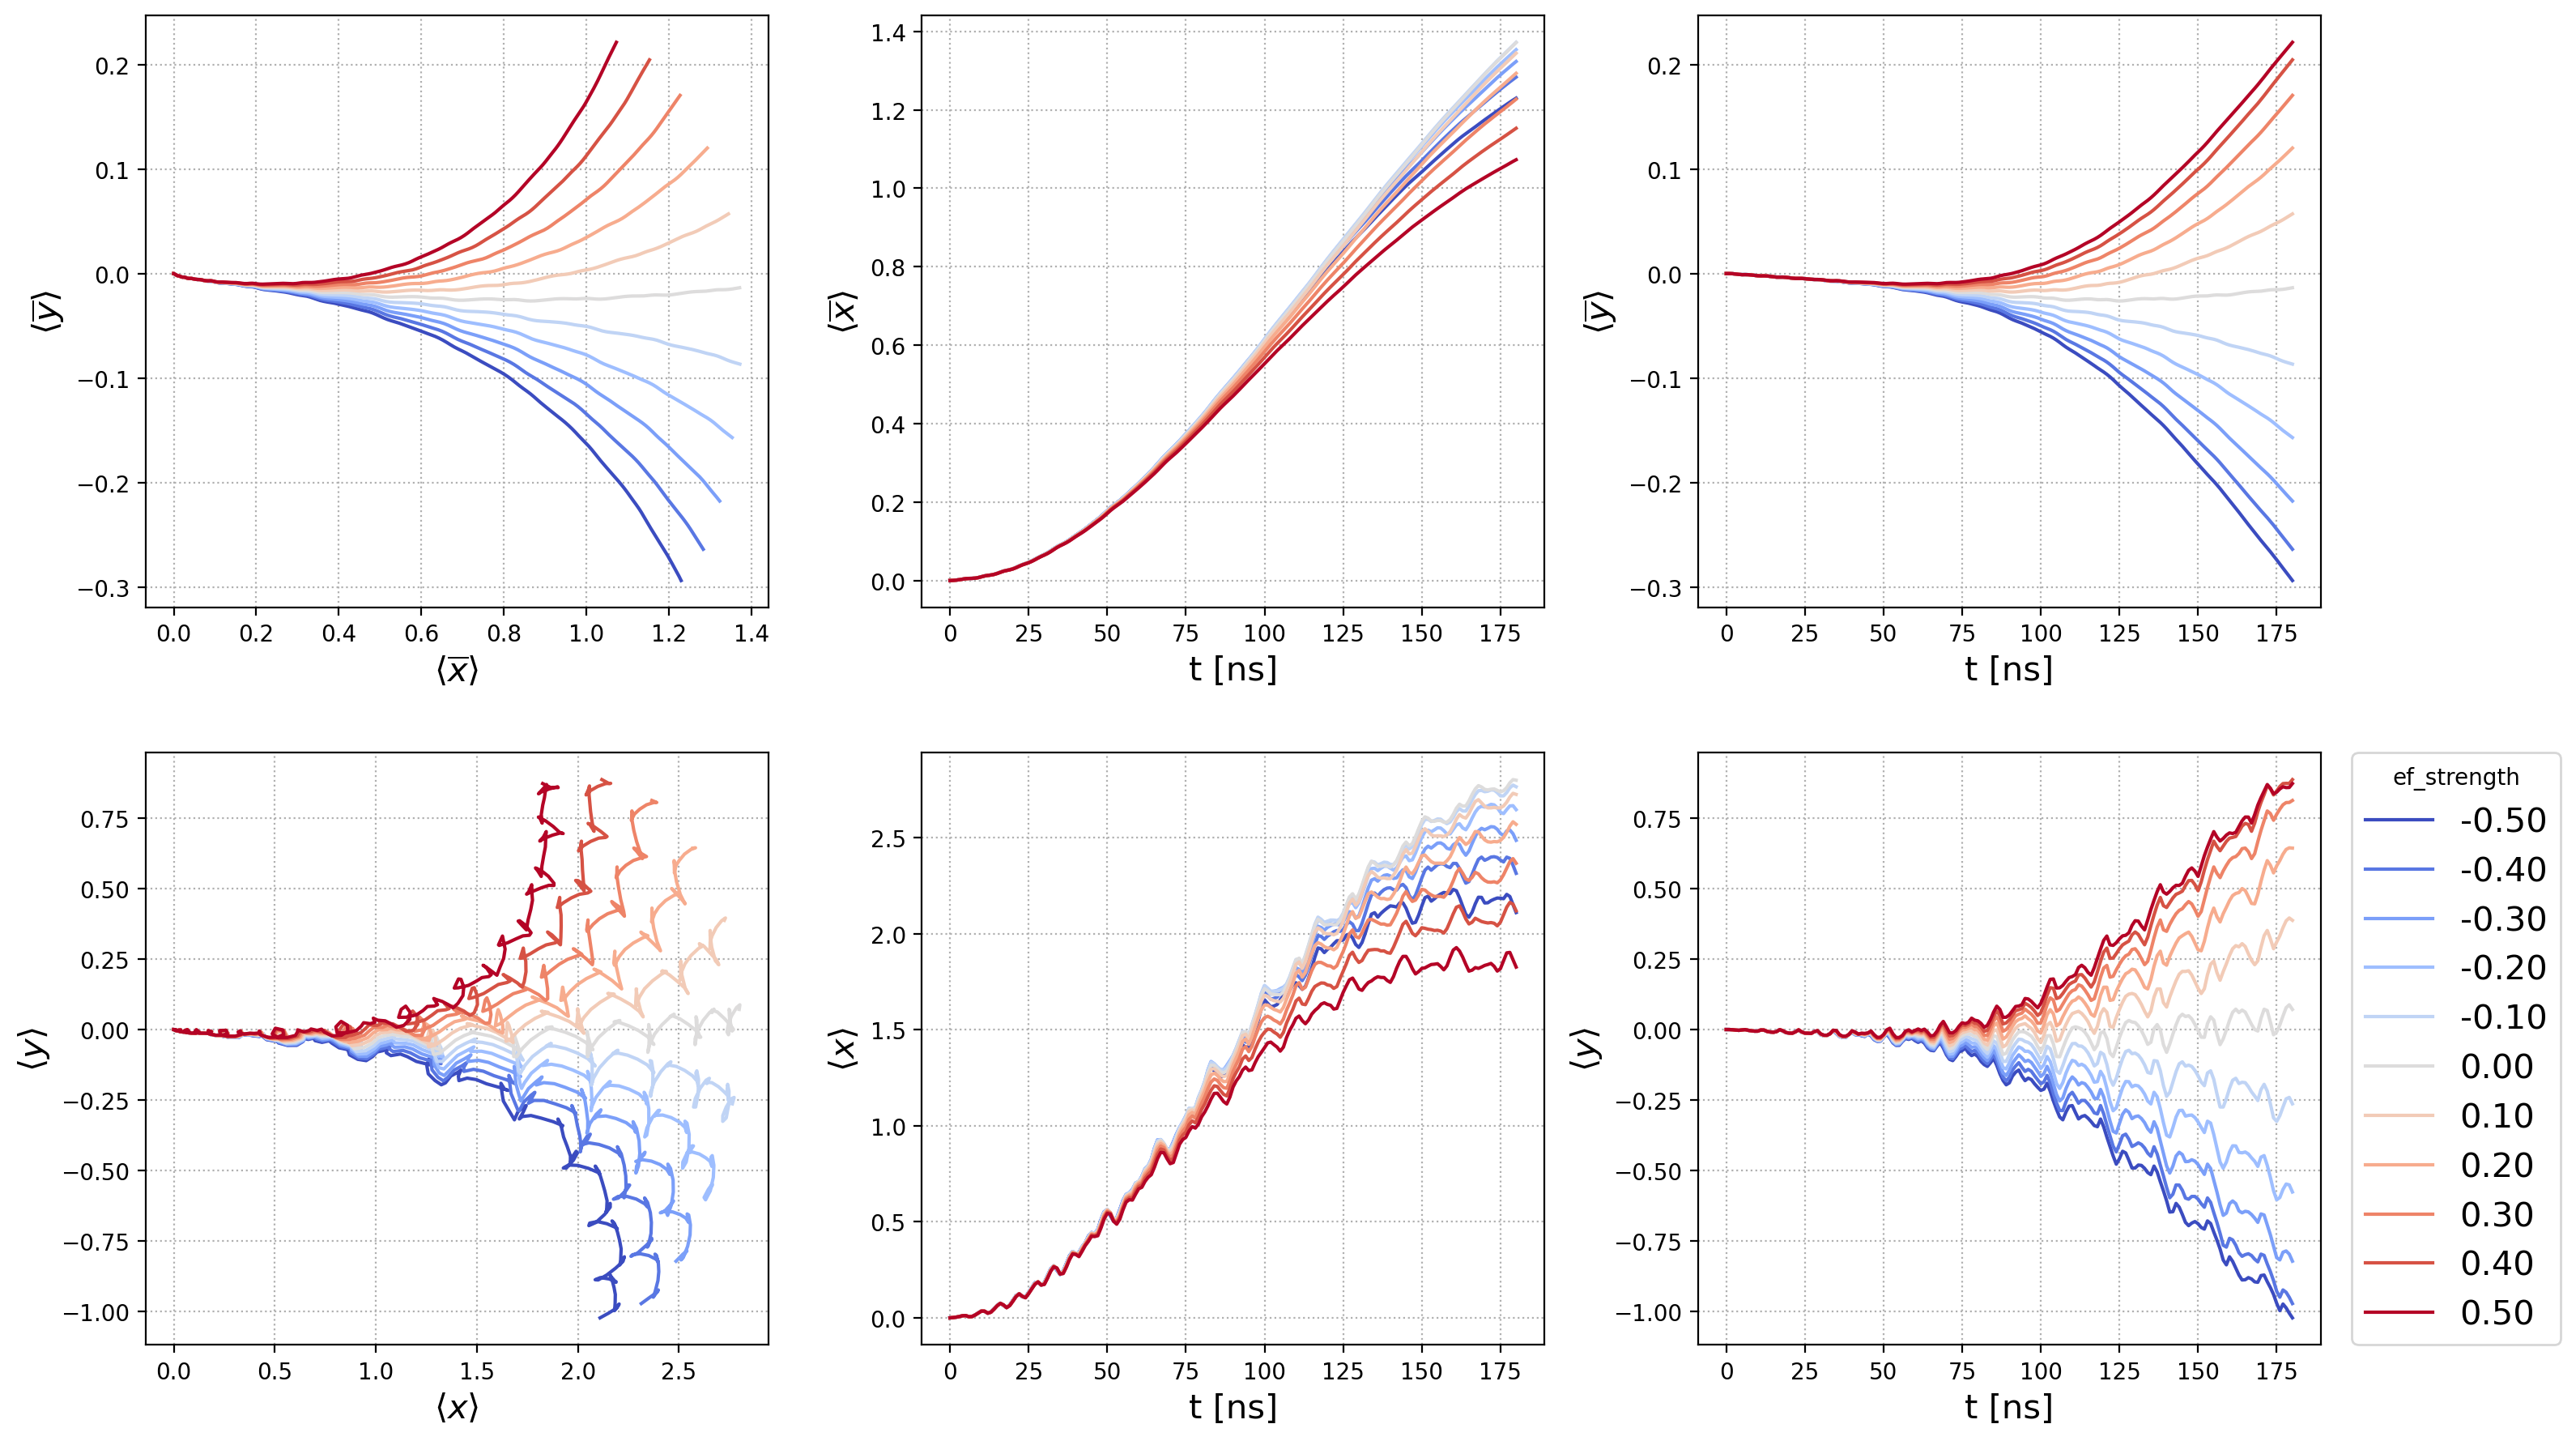

In [9]:
Phi = pi / 12

experiment_config_base = {'launch_code': 4,

                    'chosen_sites': [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14), (8, 13), (12,)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': None, 
                    'site_monitor_id_list': [3, 2, 1, 0, 7, 6, 5, 4, 11, 10, 9, 8, 15, 14, 13, 12],

                    'operating_time_points': np.linspace(0, 1.8e2, int(1.8e2 + 1)), # ns
                    'phi_list': [Phi], 'ef_strength_list': np.linspace(-0.5, 0.5, 11),

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

Successfully simulates idealized Harper-Hofstadter model. Due to disorder trajectories shift with time from their idealized paths

In [ ]:
from IPython.display import display, HTML, Image

display(
HTML(f"""
<div style="display:flex; gap:10px;">
    <img src="Pictures/choice-of-gauge-4x4.jpg" width="400" height="300">
    <img src="Pictures/axes-4x4.png" width="300" height="300">
</div>
"""),
HTML(f"""
<div style="display:flex; gap:10px;">
    <img src="Pictures/freqs-layout-4x4.png" width="400" height="300">
    <img src="Pictures/plaquette-4x4.png" width="300" height="300">
</div>
""")
)



#### Hall coefficients

[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    4.3s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    4.3s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    4.4s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    4.5s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    4.5s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:    4.6s finished
[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done  21 out of  21 | elapsed:   

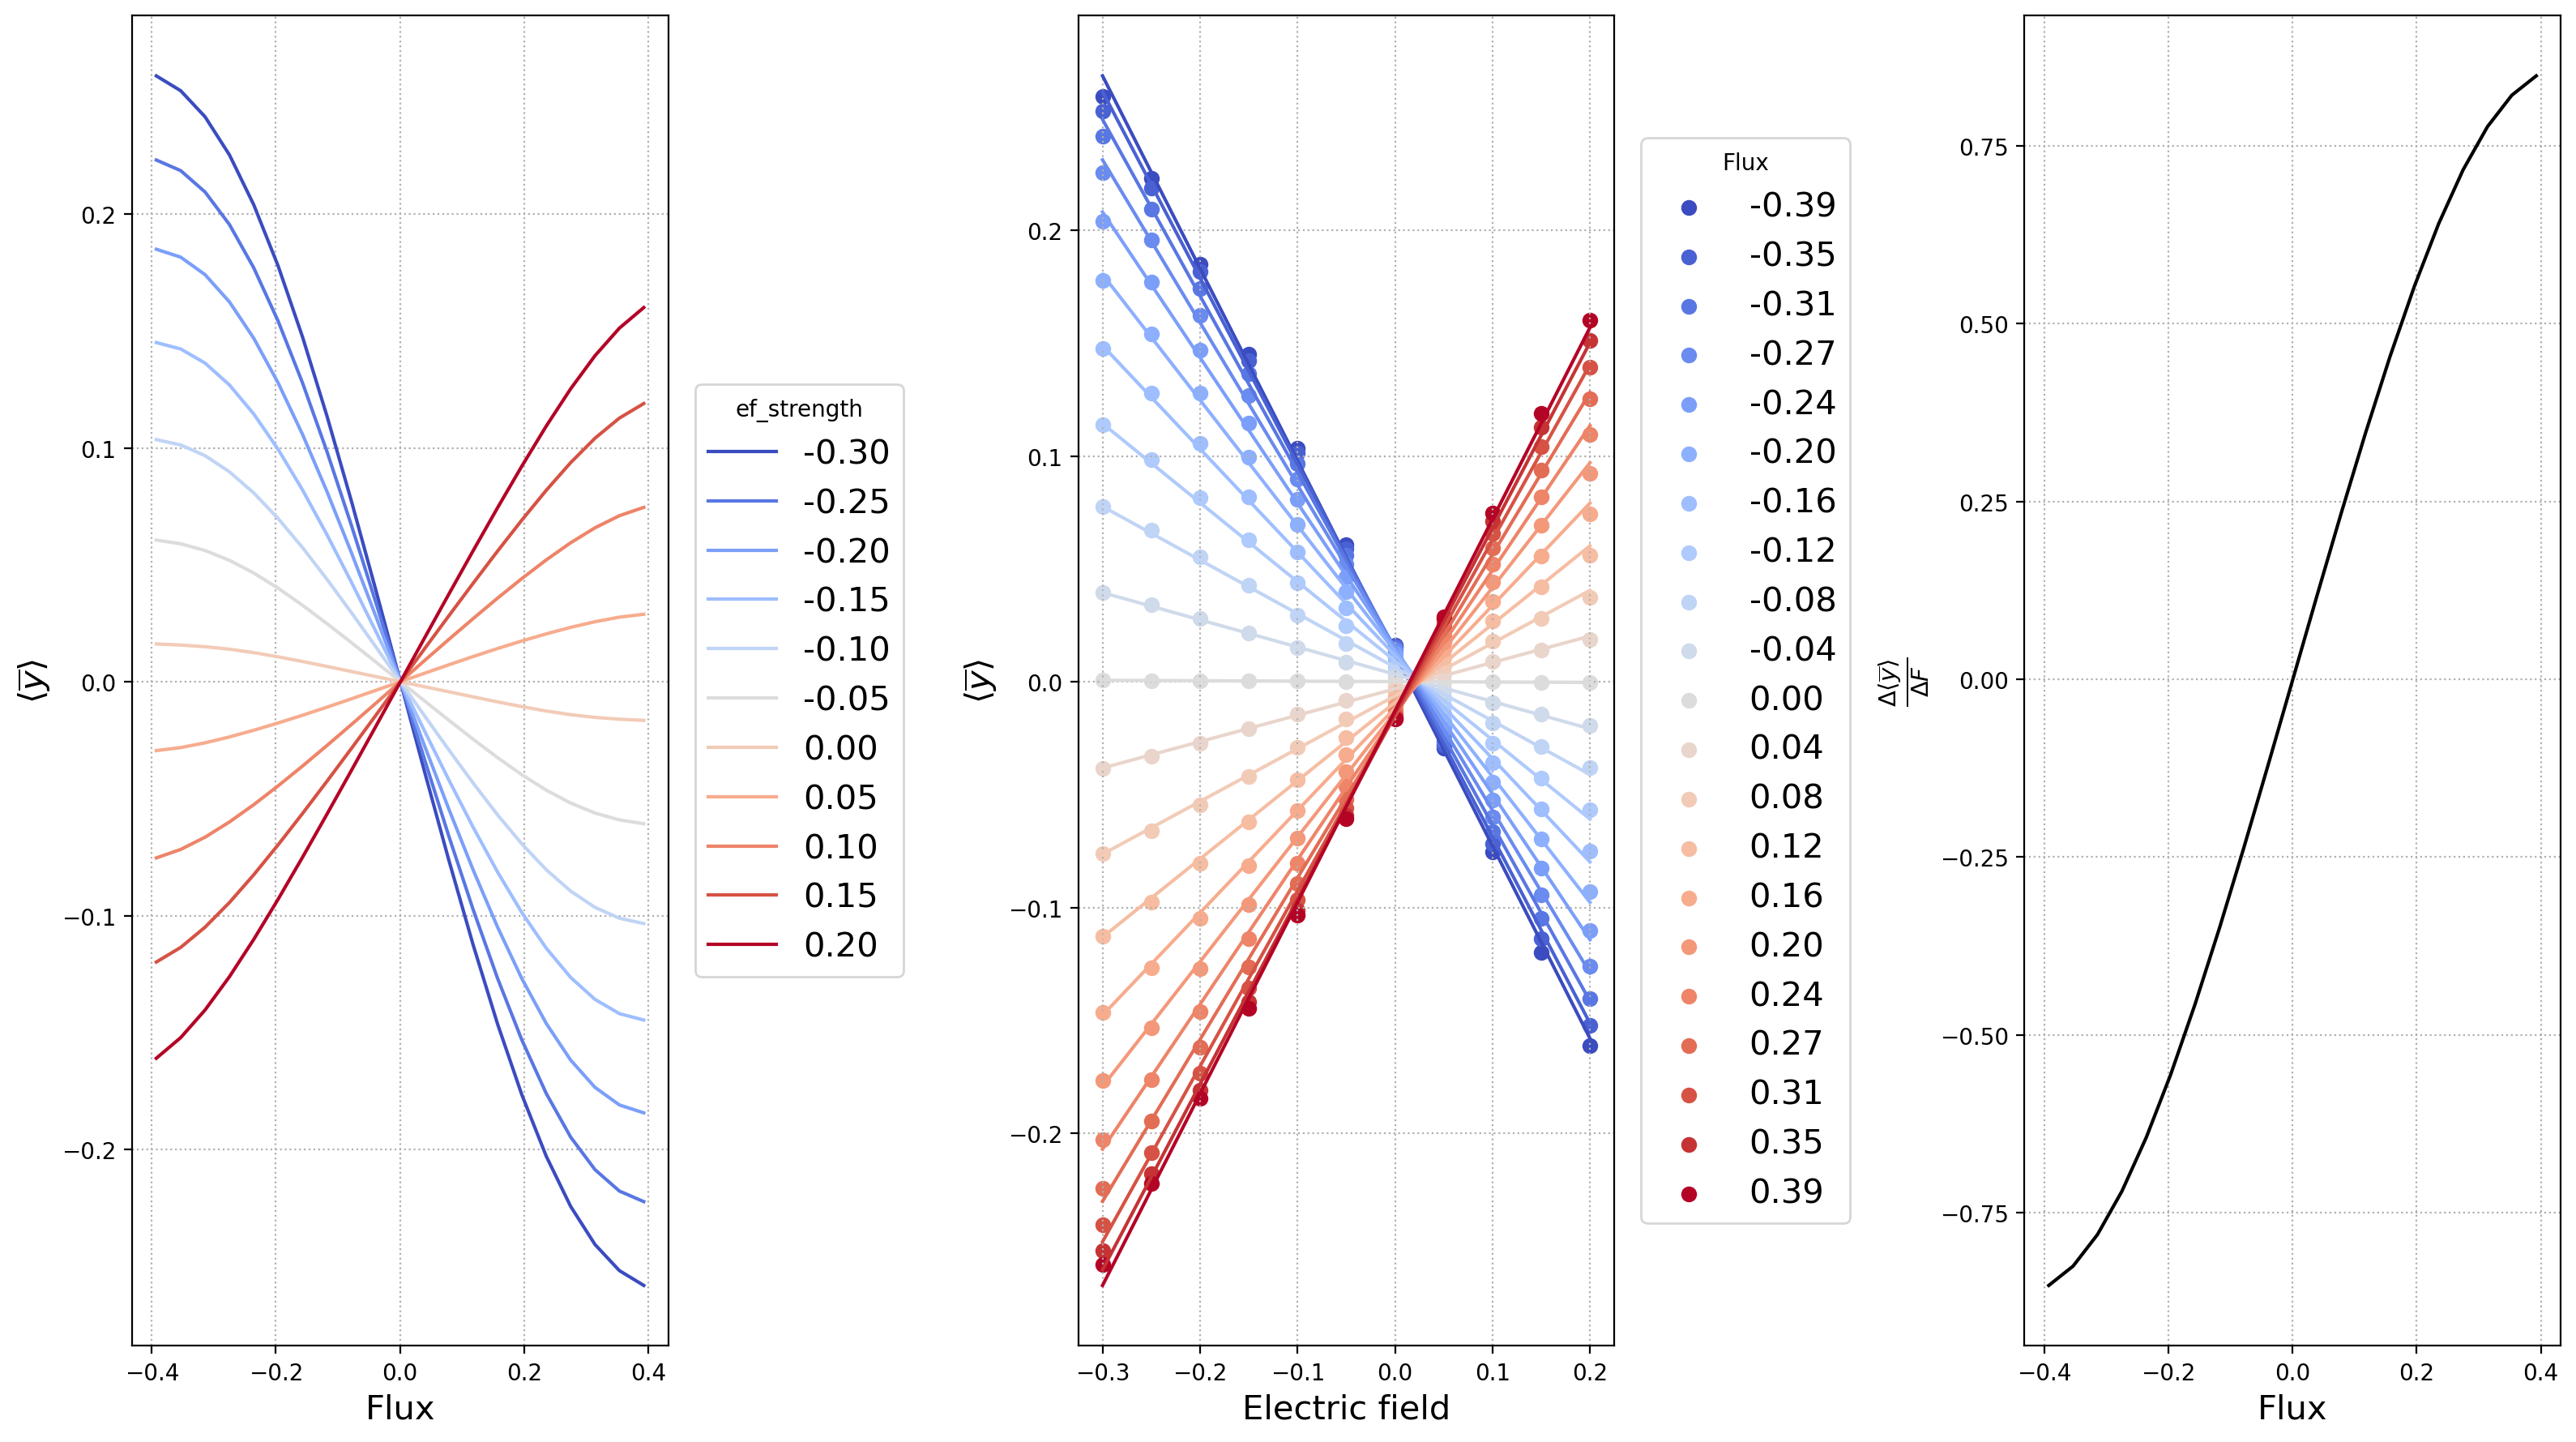

In [10]:
# '0': 4.675 * 2 * pi, '1': 4.5 * 2 * pi, '2': 4.625 * 2 * pi, '3': 4.775 * 2 * pi,
# '4': 4.55 * 2 * pi, '8': 4.725 * 2 * pi, '12': 4.83 * 2 * pi

experiment_config_base = {'launch_code': 5,

                    'chosen_sites': [(3,), (2, 7), (1, 6, 11), (0, 5, 10, 15), (4, 9, 14), (8, 13), (12,)],
                    'site_exc_id': [3], 'site_fock_number': [1], 'site_modul_id': None, 
                    'site_monitor_id_list': [3, 2, 1, 0, 7, 6, 5, 4, 11, 10, 9, 8, 15, 14, 13, 12],

                    'operating_time_points': np.linspace(0, 0.18e3, int(0.18e3 + 1)), # ns
                    'phi_list': np.linspace(-pi / 8, pi / 8, 21), 'ef_strength_list': np.linspace(-0.3, 0.2, 11), # np.linspace(-0.3, 0.2, 11), np.array([-0.3, 0, 0.2])

                    'dc_freqs': {},
                    'modul_ampls': {},
                    'modul_freqs': {},
                    'modul_phases': {},

                    'drive_ampl_factor': None,
                    'drive_ampls': {},
                    'drive_freqs': {},
                    'drive_phases': {}}
experiment_config_list = SetUpExperiment(processor, experiment_config_base)

processor.LaunchExperiment(experiment_config_list)

- It is seen that when electric field is zero there is still transverse deflection of the particle resulting from disorder of the hopping rates. So even at zero e-field inversion symmetry in configuration space is broke. <br>
- At the same time when magnetic field is zero then, as expected, time-reversal symmetry is preserved, hence we are in the axes of parameters of mirror antisymmetry, so there is no transverse deflection at all